# Final Sign Language Recognition with Leap Motion Data (Transformer, Palm Reference)

This notebook contains the finalized **Transformer-only** pipeline using **Leap Motion data only** with **132 features**.

Pipeline stages:
1. Imports and reproducibility setup
2. Feature extraction from Leap CSV frames (132 raw features)
3. Segment loading from annotation TXT files
4. Segment extraction and quality filtering
5. Sliding-window sequence generation
6. Train/val/test split (dev users + lockbox test user)
7. Label encoding and dataset preparation
8. Model training and evaluation
9. Metrics, visualizations, and streaming online WER


## 1) Imports and Setup


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import re
import subprocess
import uuid
from collections import Counter, defaultdict, deque
from datetime import datetime, timezone
from pathlib import Path
from typing import Callable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import json


try:
    from IPython import get_ipython
except Exception:
    get_ipython = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic behavior can make training slower, but helps reproducibility.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2) Central Configuration, Project Paths, and Feature Definition


In [2]:
# Central configuration

# Label used for unlabeled gaps between annotated signs.
BACKGROUND_LABEL = "background"

# Dataset split setup: train/validation come from the development users, test stays user-held-out.
DEV_USERS = ["user1", "user2", "user5"]
TEST_USER = "user3"
DEV_VAL_RATIO = 0.2
DEV_VAL_SEED = SEED + 202

# Window generation for left-aligned training clips.
WINDOW_SIZE = 30
STRIDE = 1

# Core training setup for the THCT-Net experiment.
MODEL_NAME = "transformer"
NORMALIZATION_NAME = "palm_ref"
EPOCHS = 5
LEARNING_RATE = 3e-4

# Streaming / online inference setup used for WER evaluation.
ONLINE_WINDOW_SIZE = WINDOW_SIZE
ONLINE_STRIDE = 1
STREAM_MODE = "left_causal"
WER_EXAMPLE_PRINT_COUNT = 5

# Decoder timing assumptions based on Leap frame rate.
LEAP_FPS = 30
MIN_SIGN_MS = 500
MIN_SIGN_FRAMES = max(1, int(round((MIN_SIGN_MS / 1000.0) * LEAP_FPS)))

# Bag-based smoothing and gating used by the online decoder.
BAG_SIZE = 5
BAG_AGGREGATION = "mean"
CONFIDENCE_THRESHOLD = 0.35
SIGN_BG_MARGIN = 0.10


def find_project_root(start_path: Path | None = None) -> Path:
    """Find project root by searching upwards for a directory containing dataset/."""
    current = (start_path or Path.cwd()).resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "dataset").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing dataset/.")


PROJECT_ROOT = Path("/kaggle/input/datasets/shoabahamed/sign-language-thesis")
DATASET_ROOT = PROJECT_ROOT / "dataset"
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")

HANDS = ["left", "right"]
FINGERS = ["thumb", "index", "middle", "ring", "pinky"]
BONES = ["metacarpal", "proximal", "intermediate", "distal"]
CARTESIAN_AXES = ["x", "y", "z"]
START_AXES = ["sx", "sy", "sz"]

FEATURE_KEYS = []

# Palm and wrist coordinates per hand.
for hand in HANDS:
    for part in ["palm", "wrist"]:
        for axis in CARTESIAN_AXES:
            FEATURE_KEYS.append(f"{hand}_{part}_{axis}")

# Finger bone start-joint coordinates per hand.
for hand in HANDS:
    for finger in FINGERS:
        for bone in BONES:
            for axis in START_AXES:
                FEATURE_KEYS.append(f"{hand}_{finger}_{bone}_{axis}")

assert len(FEATURE_KEYS) == 132, f"Expected 132 features, got {len(FEATURE_KEYS)}"
print(f"Feature count: {len(FEATURE_KEYS)}")

FEATURE_INDEX = {key: idx for idx, key in enumerate(FEATURE_KEYS)}
PALM_TRIPLETS: dict[str, tuple[int, int, int]] = {}
HAND_POSITION_TRIPLETS: dict[str, list[tuple[int, int, int]]] = {}

for hand in HANDS:
    PALM_TRIPLETS[hand] = tuple(FEATURE_INDEX[f"{hand}_palm_{axis}"] for axis in CARTESIAN_AXES)

    triplets: list[tuple[int, int, int]] = []
    triplets.append(tuple(FEATURE_INDEX[f"{hand}_wrist_{axis}"] for axis in CARTESIAN_AXES))
    for finger in FINGERS:
        for bone in BONES:
            triplets.append(tuple(FEATURE_INDEX[f"{hand}_{finger}_{bone}_{axis}"] for axis in START_AXES))
    HAND_POSITION_TRIPLETS[hand] = triplets


Project root: /kaggle/input/datasets/shoabahamed/sign-language-thesis
Dataset root: /kaggle/input/datasets/shoabahamed/sign-language-thesis/dataset
Feature count: 132


## 3) Frame-Level Feature Extraction

The function below converts one Leap CSV row into a fixed (132,) numeric vector.
Missing columns or invalid values are safely converted to 0.0 to keep the pipeline robust.

In [3]:
def _safe_float(value, default: float = 0.0) -> float:
    """Convert values to float safely; return default on invalid input."""
    try:
        if pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


def palm_reference_normalize_frame(frame: np.ndarray) -> np.ndarray:
    """Normalize one frame by subtracting each hand palm from that hand coordinates.

    Input shape: (132,)
    Output shape: (132,)
    """
    out = np.asarray(frame, dtype=np.float32).copy()
    if out.shape[0] != len(FEATURE_KEYS):
        raise ValueError(f"Expected frame with {len(FEATURE_KEYS)} features, got {out.shape[0]}")

    for hand in HANDS:
        px, py, pz = PALM_TRIPLETS[hand]
        palm = out[[px, py, pz]].copy()
        if not np.all(np.isfinite(palm)):
            palm = np.zeros((3,), dtype=np.float32)

        for ix, iy, iz in HAND_POSITION_TRIPLETS[hand]:
            out[ix] = out[ix] - palm[0]
            out[iy] = out[iy] - palm[1]
            out[iz] = out[iz] - palm[2]

        # Keep palm channels for stable shape and explicit origin anchoring.
        out[px] = 0.0
        out[py] = 0.0
        out[pz] = 0.0

    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)


def palm_reference_normalize_sequence(sequence: np.ndarray) -> np.ndarray:
    """Apply palm-reference normalization frame-wise.

    Input shape: (T, D)
    Output shape: (T, D)
    """
    seq = np.asarray(sequence, dtype=np.float32)
    if seq.ndim != 2:
        raise ValueError(f"Expected sequence with shape (T, D), got {seq.shape}")
    if seq.shape[0] == 0:
        return seq.astype(np.float32, copy=False)

    normalized = np.empty_like(seq, dtype=np.float32)
    for i in range(seq.shape[0]):
        normalized[i] = palm_reference_normalize_frame(seq[i])
    return normalized


def extract_features_from_row(row: pd.Series) -> np.ndarray:
    """Convert one Leap CSV row to one 132-D raw feature frame (no normalization)."""
    values = np.asarray([_safe_float(row.get(key, 0.0)) for key in FEATURE_KEYS], dtype=np.float32)
    return np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)


# Quick structural self-check with a synthetic row.
test_row = pd.Series({key: 1.0 for key in FEATURE_KEYS[:5]})
test_features = extract_features_from_row(test_row)
print(f"Feature vector shape: {test_features.shape}")

Feature vector shape: (132,)


## 4) Load Segmentation and Leap CSV Data

- load_segments(path) reads annotation TXT files (start_frame end_frame label).
- load_leap_csv(path) loads frame-level data and converts each frame to 132 raw features.

In [4]:
def load_segments(path: Path) -> list[dict]:
    """Load segmentation file into a list of {start, end, label} dictionaries."""
    path = Path(path)
    if not path.exists():
        return []

    # The file format is whitespace-separated with no headers.
    df = pd.read_csv(path, sep=r"\s+", header=None, names=["start", "end", "label"], engine="python")
    segments = []

    for _, row in df.iterrows():
        try:
            start = int(row["start"])
            end = int(row["end"])
            label = str(row["label"]).strip()
            if label:
                segments.append({"start": start, "end": end, "label": label})
        except Exception:
            # Skip malformed rows to avoid interrupting the full data scan.
            continue

    return segments


def load_leap_csv(path: Path, return_dataframe: bool = False):
    """Load Leap CSV and return feature matrix (num_frames, 132)."""
    path = Path(path)
    if not path.exists():
        empty = np.zeros((0, len(FEATURE_KEYS)), dtype=np.float32)
        return (empty, pd.DataFrame()) if return_dataframe else empty

    df = pd.read_csv(path)
    if df.empty:
        empty = np.zeros((0, len(FEATURE_KEYS)), dtype=np.float32)
        return (empty, df) if return_dataframe else empty

    feature_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Extracting {path.name}", leave=False):
        feature_rows.append(extract_features_from_row(row))

    features = np.vstack(feature_rows).astype(np.float32)
    return (features, df) if return_dataframe else features

## 5) Recording Discovery and Segment Extraction (Sign + Background)

Each user recording is matched by recording ID (for example `P1_S1_R1`) between:
- Leap CSV file
- Segmentation TXT file

For each recording, we build segment intervals for:
- Annotated sign glosses from segmentation files
- Background gloss from unannotated frame gaps between signs

This gives pseudo ground-truth intervals for both sign and background classes.

In [5]:
RECORDING_ID_PATTERN = re.compile(r"(P\d+_S\d+_R\d+)", re.IGNORECASE)


def extract_recording_id(filename: str) -> str | None:
    """Extract canonical recording ID from a CSV or TXT filename."""
    match = RECORDING_ID_PATTERN.search(filename)
    return match.group(1) if match else None


def find_user_recordings(dataset_root: Path) -> dict[str, list[dict]]:
    """Find matching (CSV, segmentation) pairs for each user directory."""
    dataset_root = Path(dataset_root)
    user_map: dict[str, list[dict]] = defaultdict(list)

    for user_dir in sorted(dataset_root.glob("user*")):
        if not user_dir.is_dir():
            continue

        leap_dir = user_dir / "leap_data"
        seg_dir = user_dir / "segmentation"
        if not leap_dir.exists() or not seg_dir.exists():
            continue

        seg_map = {}
        for seg_path in seg_dir.glob("*.txt"):
            recording_id = extract_recording_id(seg_path.name)
            if recording_id is not None:
                seg_map[recording_id] = seg_path

        for csv_path in leap_dir.glob("*.csv"):
            recording_id = extract_recording_id(csv_path.name)
            if recording_id is None:
                continue

            seg_path = seg_map.get(recording_id)
            if seg_path is not None:
                user_map[user_dir.name].append({
                    "recording_id": recording_id,
                    "csv_path": csv_path,
                    "seg_path": seg_path,
                })

    return user_map


def build_intervals_with_background(segment_defs: list[dict], num_frames: int, background_label: str = BACKGROUND_LABEL) -> list[dict]:
    """Build labeled intervals including background gaps between annotated signs."""
    if num_frames <= 0:
        return []

    cleaned = []
    for seg in segment_defs:
        try:
            start = max(0, int(seg["start"]))
            end = min(num_frames - 1, int(seg["end"]))
            label = str(seg["label"]).strip()
            if end >= start and label:
                cleaned.append({"start": start, "end": end, "label": label, "is_background": False})
        except Exception:
            continue

    cleaned.sort(key=lambda x: (x["start"], x["end"]))
    intervals = []
    prev_end = -1

    for seg in cleaned:
        if seg["start"] > prev_end + 1:
            intervals.append({
                "start": prev_end + 1,
                "end": seg["start"] - 1,
                "label": background_label,
                "is_background": True,
            })

        intervals.append(seg)
        prev_end = max(prev_end, seg["end"])

    if prev_end < num_frames - 1:
        intervals.append({
            "start": prev_end + 1,
            "end": num_frames - 1,
            "label": background_label,
            "is_background": True,
        })

    return intervals


def extract_segments_for_recording(csv_path: Path, seg_path: Path) -> list[dict]:
    """Return per-interval records for one recording, including background gaps."""
    features, raw_df = load_leap_csv(csv_path, return_dataframe=True)
    segment_defs = load_segments(seg_path)

    if features.shape[0] == 0:
        return []

    interval_defs = build_intervals_with_background(segment_defs, num_frames=features.shape[0])
    if not interval_defs:
        return []

    confidence_cols = [col for col in ["left_confidence", "right_confidence"] if col in raw_df.columns]
    records = []

    for seg in interval_defs:
        start = max(0, int(seg["start"]))
        end = min(features.shape[0] - 1, int(seg["end"]))
        if end < start:
            continue

        segment_array = features[start:end + 1]
        if segment_array.size == 0:
            continue

        segment_confidence = None
        if confidence_cols:
            conf_slice = raw_df.loc[start:end, confidence_cols].to_numpy(dtype=np.float32)
            if conf_slice.size > 0:
                # Average confidence across available hands for each frame.
                segment_confidence = np.nanmean(conf_slice, axis=1)

        records.append({
            "segment": segment_array.astype(np.float32),
            "label": seg["label"],
            "confidence": segment_confidence,
            "segment_span": (start, end),
            "recording_features": features,
            "is_background": bool(seg.get("is_background", False)),
        })

    return records


user_recordings = find_user_recordings(DATASET_ROOT)
if not user_recordings:
    raise RuntimeError("No matching Leap CSV and segmentation TXT pairs were found.")

print("Matched recordings per user:")
for user_name, recs in user_recordings.items():
    print(f"  {user_name}: {len(recs)} recordings")

segments_by_user: dict[str, list[dict]] = defaultdict(list)
for user_name, recordings in user_recordings.items():
    for rec in tqdm(recordings, desc=f"Extracting segments for {user_name}"):
        rec_segments = extract_segments_for_recording(rec["csv_path"], rec["seg_path"])
        for item in rec_segments:
            item["recording_id"] = rec["recording_id"]
        segments_by_user[user_name].extend(rec_segments)

all_segments_raw = [s for lst in segments_by_user.values() for s in lst]
segment_label_pairs = [(s["segment"], s["label"]) for s in all_segments_raw]

print(f"\nTotal raw segments (sign + background): {len(all_segments_raw)}")
print(f"Tuple storage format sample: (segment_array, label) -> {len(segment_label_pairs)} items")
print("Raw class distribution (segments):")
print(Counter([s["label"] for s in all_segments_raw]))


Matched recordings per user:
  user1: 76 recordings
  user2: 73 recordings
  user3: 55 recordings
  user5: 72 recordings


Extracting segments for user1:   0%|          | 0/76 [00:00<?, ?it/s]

Extracting P1_S7_R5.csv:   0%|          | 0/750 [00:00<?, ?it/s]

Extracting P1_S10_R1.csv:   0%|          | 0/750 [00:00<?, ?it/s]

Extracting P1_S2_R5.csv:   0%|          | 0/750 [00:00<?, ?it/s]

...

Extracting P5_S8_R6.csv:   0%|          | 0/750 [00:00<?, ?it/s]

Extracting P5_S2_R3.csv:   0%|          | 0/750 [00:00<?, ?it/s]

Extracting P5_S3_R3.csv:   0%|          | 0/750 [00:00<?, ?it/s]

Extracting P5_S4_R1.csv:   0%|          | 0/750 [00:00<?, ?it/s]


Total raw segments (sign + background): 2293
Tuple storage format sample: (segment_array, label) -> 2293 items
Raw class distribution (segments):
Counter({'background': 1284, 'FARMING': 58, 'BIG': 58, 'SMALL': 55, 'COME': 53, 'VAN': 53, 'GO': 52, 'READ': 51, 'GREETINGS': 51, 'BOAT': 50, 'OUR': 50, 'FEBRUARY': 49, 'DRIVER': 48, 'BIRD': 48, 'WRITE': 48, 'UGLY': 48, 'AUGUST': 48, 'TIGER': 48, 'WHICH': 48, 'TRAIN': 47, 'WHAT': 46})


## 6) User-Based Split Setup + Segment Filtering

Before building train/validation/test windows, we enforce a strict user split:
1. `user1` and `user2` are **development users**: segments are filtered, then split by **recording** into train / val (`DEV_VAL_RATIO`, default 0.15).
2. `user3` is the **lockbox test user**: all segments go to test only (never used for training or early stopping).

Filtering rules for train/validation/test segments:
1. Missing data: discard if more than 40% of frames are near-zero
2. Low confidence: if confidence columns exist and average confidence < 0.1
3. Too short: discard if segment length < 10 frames


In [6]:


def dedupe_consecutive_labels(labels: list[str]) -> list[str]:
    """Collapse consecutive duplicate labels while preserving order."""
    if not labels:
        return []
    out = [labels[0]]
    for label in labels[1:]:
        if label != out[-1]:
            out.append(label)
    return out


def near_zero_frame_ratio(segment: np.ndarray, eps: float = 1e-6) -> float:
    """Compute fraction of frames whose L2 norm is almost zero."""
    if segment.size == 0:
        return 1.0
    frame_norm = np.linalg.norm(segment, axis=1)
    return float(np.mean(frame_norm < eps))


def build_recording_catalog(segments_by_user_map: dict[str, list[dict]], background_label: str = BACKGROUND_LABEL) -> list[dict]:
    """Aggregate interval-level records into recording-level continuous samples."""
    rec_map: dict[tuple[str, str], dict] = {}

    for user_name, items in segments_by_user_map.items():
        for item in items:
            recording_id = str(item.get("recording_id", "unknown"))
            key = (user_name, recording_id)
            if key not in rec_map:
                rec_map[key] = {
                    "user": user_name,
                    "recording_id": recording_id,
                    "V": item["recording_features"].astype(np.float32),
                    "intervals": [],
                }

            start, end = item["segment_span"]
            rec_map[key]["intervals"].append({
                "start": int(start),
                "end": int(end),
                "label": str(item["label"]),
                "is_background": bool(item.get("is_background", False)),
            })

    catalog = []
    for rec in rec_map.values():
        intervals = sorted(rec["intervals"], key=lambda x: (x["start"], x["end"]))
        segmentation_regions = [
            {
                "label": str(seg["label"]),
                "start_frame": int(seg["start"]),
                "end_frame": int(seg["end"]),
            }
            for seg in intervals
            if seg["label"] != background_label
        ]
        gt_labels = [seg["label"] for seg in segmentation_regions]
        gt_labels = dedupe_consecutive_labels(gt_labels)
        missing_ratio = near_zero_frame_ratio(rec["V"])
        catalog.append({
            "user": rec["user"],
            "recording_id": rec["recording_id"],
            "V": rec["V"],
            "ground_truth": gt_labels,
            "segmentation_regions": segmentation_regions,
            "missing_ratio": float(missing_ratio),
            "num_frames": int(rec["V"].shape[0]),
        })

    return catalog


def split_dev_recordings(
    catalog: list[dict],
    dev_users: list[str],
    val_ratio: float = DEV_VAL_RATIO,
    seed: int = DEV_VAL_SEED,
) -> tuple[set[tuple[str, str]], set[tuple[str, str]]]:
    """Split development recordings into train/val keys (recording-level, no window leakage)."""
    dev_recs = [
        rec for rec in catalog
        if rec["user"] in dev_users and len(rec.get("ground_truth", [])) > 0
    ]
    if len(dev_recs) == 0:
        raise RuntimeError("No development recordings with non-empty ground truth were found.")

    rng = random.Random(seed)
    rng.shuffle(dev_recs)

    n = len(dev_recs)
    n_val = max(1, int(round(n * val_ratio))) if n > 1 else 0
    if n_val >= n:
        n_val = max(1, n - 1)

    val_recs = dev_recs[:n_val]
    train_recs = dev_recs[n_val:]

    train_keys = {(rec["user"], rec["recording_id"]) for rec in train_recs}
    val_keys = {(rec["user"], rec["recording_id"]) for rec in val_recs}
    return train_keys, val_keys


def filter_segments(segments: list[dict], min_len: int = 10, max_zero_ratio: float = 0.40, min_confidence: float = 0.1):
    """Return filtered segments and a reason counter for removed segments."""
    kept = []
    removed_reasons = Counter()

    for item in segments:
        segment = item["segment"]
        conf = item.get("confidence", None)
        reasons = []

        if len(segment) < min_len:
            reasons.append("too_short")
        if near_zero_frame_ratio(segment) > max_zero_ratio:
            reasons.append("missing_data")
        if conf is not None and len(conf) > 0:
            avg_conf = float(np.nanmean(conf))
            if np.isnan(avg_conf) or avg_conf < min_confidence:
                reasons.append("low_confidence")

        if reasons:
            for reason in reasons:
                removed_reasons[reason] += 1
            continue

        kept.append(item)

    return kept, removed_reasons


available_users = sorted(segments_by_user.keys())
dataset_users = sorted([p.name for p in DATASET_ROOT.glob("user*") if p.is_dir()])
missing_dev_users = [u for u in DEV_USERS if u not in available_users]

if missing_dev_users:
    missing_detail = []
    for user_name in missing_dev_users:
        if user_name in dataset_users:
            missing_detail.append(
                f"{user_name} exists in dataset but has no matched CSV+TXT recording pairs"
            )
        else:
            missing_detail.append(f"{user_name} folder not found under dataset/")
    raise RuntimeError(
        "Missing required development users after recording discovery. "
        + "; ".join(missing_detail)
        + f". Available discovered users: {available_users}"
    )

if TEST_USER not in available_users:
    if TEST_USER in dataset_users:
        raise RuntimeError(
            f"Test user '{TEST_USER}' exists in dataset but has no matched CSV+TXT recording pairs. "
            f"Discovered users with matched pairs: {available_users}"
        )
    raise RuntimeError(
        f"Test user '{TEST_USER}' folder is missing under dataset/. "
        f"Available discovered users: {available_users}"
    )

recording_catalog = build_recording_catalog(segments_by_user)
if len(recording_catalog) == 0:
    raise RuntimeError("No recording-level continuous samples were found.")

dev_train_recording_keys, dev_val_recording_keys = split_dev_recordings(
    catalog=recording_catalog,
    dev_users=DEV_USERS,
    val_ratio=DEV_VAL_RATIO,
    seed=DEV_VAL_SEED,
)

# Raw segment pools before filtering.
dev_segments_pool: list[dict] = []
test_segments_pool: list[dict] = []

for user_name, user_segments in segments_by_user.items():
    for item in user_segments:
        item_with_user = dict(item)
        item_with_user["user"] = user_name
        if user_name in DEV_USERS:
            dev_segments_pool.append(item_with_user)
        elif user_name == TEST_USER:
            test_segments_pool.append(item_with_user)

dev_segments_filtered, dev_removed = filter_segments(dev_segments_pool)
test_segments_filtered, test_removed = filter_segments(test_segments_pool)

# Route dev segments by recording key; test segments all go to test.
filtered_train_segments: list[dict] = []
filtered_val_segments: list[dict] = []

for item in dev_segments_filtered:
    key = (item.get("user", "unknown"), str(item.get("recording_id", "unknown")))
    if key in dev_train_recording_keys:
        filtered_train_segments.append(item)
    elif key in dev_val_recording_keys:
        filtered_val_segments.append(item)

filtered_test_segments = list(test_segments_filtered)

test_raw_count = len(test_segments_pool)

print("========== TRAIN / VAL / TEST SPLIT (RECORDING-LEVEL) ==========")
print(f"Development users       : {DEV_USERS}")
print(f"Test user (lockbox)     : {TEST_USER}")
print(f"DEV_VAL_RATIO           : {DEV_VAL_RATIO}")
print(f"DEV_VAL_SEED            : {DEV_VAL_SEED}")
print(f"Total recordings in catalog: {len(recording_catalog)}")
print(f"Dev train recordings    : {len(dev_train_recording_keys)}")
print(f"Dev val recordings      : {len(dev_val_recording_keys)}")
print(f"Test recordings (user3) : {len([r for r in recording_catalog if r['user'] == TEST_USER])}")
print(f"Dev removed by filter   : {dict(dev_removed)}")
print(f"Test removed by filter  : {dict(test_removed)}")
print(f"Train segments (filtered): {len(filtered_train_segments)}")
print(f"Val segments (filtered)  : {len(filtered_val_segments)}")
print(f"Test segments (filtered) : {len(filtered_test_segments)}")

if len(filtered_train_segments) == 0:
    raise RuntimeError("Training segment pool is empty. Check DEV_VAL_RATIO or development data.")
if len(filtered_val_segments) == 0:
    raise RuntimeError("Validation segment pool is empty. Check DEV_VAL_RATIO or development data.")
if len(filtered_test_segments) == 0:
    raise RuntimeError("Test segment pool is empty. Check TEST_USER and data availability.")

print("Sample dev val recording IDs:", sorted({r for _, r in dev_val_recording_keys})[:5])
print("Sample test recording IDs:", sorted({r["recording_id"] for r in recording_catalog if r["user"] == TEST_USER})[:5])

# WER catalogs (continuous recordings with gloss GT).
test_wer_catalog = [
    rec for rec in recording_catalog
    if rec["user"] == TEST_USER and len(rec.get("ground_truth", [])) > 0
]
dev_val_wer_catalog = [
    rec for rec in recording_catalog
    if (rec["user"], rec["recording_id"]) in dev_val_recording_keys and len(rec.get("ground_truth", [])) > 0
]
dev_train_wer_catalog = [
    rec for rec in recording_catalog
    if (rec["user"], rec["recording_id"]) in dev_train_recording_keys and len(rec.get("ground_truth", [])) > 0
]

print(f"WER catalog sizes -> train(dev): {len(dev_train_wer_catalog)}, val(dev): {len(dev_val_wer_catalog)}, test: {len(test_wer_catalog)}")

# Per-user filtered segment maps for reporting.
filtered_train_segments_by_user: dict[str, list[dict]] = defaultdict(list)
filtered_val_segments_by_user: dict[str, list[dict]] = defaultdict(list)
filtered_test_segments_by_user: dict[str, list[dict]] = defaultdict(list)

for item in filtered_train_segments:
    filtered_train_segments_by_user[str(item.get("user", "unknown"))].append(item)
for item in filtered_val_segments:
    filtered_val_segments_by_user[str(item.get("user", "unknown"))].append(item)
for item in filtered_test_segments:
    filtered_test_segments_by_user[str(item.get("user", "unknown"))].append(item)

dev_segments_all: dict[str, list[dict]] = defaultdict(list)
for item in dev_segments_filtered:
    dev_segments_all[str(item.get("user", "unknown"))].append(item)

print("Filtered class distribution (train segments):")
print(Counter([s["label"] for s in filtered_train_segments]))
print("Filtered class distribution (val segments):")
print(Counter([s["label"] for s in filtered_val_segments]))
print("Filtered class distribution (test segments):")
print(Counter([s["label"] for s in filtered_test_segments]))


========== TRAIN / VAL / TEST SPLIT (RECORDING-LEVEL) ==========
Development users       : ['user1', 'user2', 'user5']
Test user (lockbox)     : user3
DEV_VAL_RATIO           : 0.2
DEV_VAL_SEED            : 244
Total recordings in catalog: 276
Dev train recordings    : 177
Dev val recordings      : 44
Test recordings (user3) : 55
Dev removed by filter   : {'missing_data': 1, 'low_confidence': 1, 'too_short': 4}
Test removed by filter  : {'too_short': 1}
Train segments (filtered): 1467
Val segments (filtered)  : 363
Test segments (filtered) : 457
Sample dev val recording IDs: ['P1_S10_R3', 'P1_S11_R3', 'P1_S1_R3', 'P1_S1_R6', 'P1_S1_R7']
Sample test recording IDs: ['P3_S10_R1', 'P3_S10_R2', 'P3_S10_R3', 'P3_S10_R4', 'P3_S10_R5']
WER catalog sizes -> train(dev): 177, val(dev): 44, test: 55
Filtered class distribution (train segments):
Counter({'background': 820, 'SMALL': 38, 'FARMING': 38, 'BIG': 38, 'VAN': 36, 'OUR': 35, 'READ': 34, 'BOAT': 33, 'WHICH': 33, 'GREETINGS': 33, 'FEBRUARY': 

## 7) Final Split: Dev Train / Dev Val / Test (`user3`)

Final segment sets:
- **Train**: filtered dev segments from train recordings (`user1`, `user2`)
- **Validation**: filtered dev segments from val recordings (`user1`, `user2`) — used for early stopping only
- **Test**: all filtered segments from `user3` (lockbox, evaluated after training)

No segment-level random split; assignment is by recording ID.


In [7]:
# Build final train/val/test segment sets.
train_segments = list(filtered_train_segments)
val_segments = list(filtered_val_segments)
test_segments = list(filtered_test_segments)

if len(train_segments) == 0:
    raise RuntimeError("Training split is empty. Check DEV_VAL_RATIO and filtering thresholds.")
if len(val_segments) == 0:
    raise RuntimeError("Validation split is empty. Check DEV_VAL_RATIO and filtering thresholds.")
if len(test_segments) == 0:
    raise RuntimeError("Test split is empty. Check TEST_USER and filtering thresholds.")

train_segments_by_user = {"all_users": train_segments}
val_segments_by_user = {"all_users": val_segments}
test_segments_by_user = {"all_users": test_segments}

print("========== FINAL SPLIT (SEGMENTS) ==========")
print(f"Development train users: {DEV_USERS}")
for user_name in DEV_USERS:
    print(f"  train {user_name}: {len(filtered_train_segments_by_user.get(user_name, []))} segments")
print(f"Development val users  : {DEV_USERS}")
for user_name in DEV_USERS:
    print(f"  val   {user_name}: {len(filtered_val_segments_by_user.get(user_name, []))} segments")
print(f"Test user              : {TEST_USER}")
print(f"  test  {TEST_USER}: {len(filtered_test_segments_by_user.get(TEST_USER, []))} segments")

print(f"Train segments total : {len(train_segments)}")
print(f"Val segments total   : {len(val_segments)}")
print(f"Test segments total  : {len(test_segments)}")

print("Train class distribution (segments):")
print(Counter([s["label"] for s in train_segments]))
print("Val class distribution (segments):")
print(Counter([s["label"] for s in val_segments]))
print("Test class distribution (segments):")
print(Counter([s["label"] for s in test_segments]))


========== FINAL SPLIT (SEGMENTS) ==========
Development train users: ['user1', 'user2', 'user5']
  train user1: 520 segments
  train user2: 405 segments
  train user5: 542 segments
Development val users  : ['user1', 'user2', 'user5']
  val   user1: 113 segments
  val   user2: 200 segments
  val   user5: 50 segments
Test user              : user3
  test  user3: 457 segments
Train segments total : 1467
Val segments total   : 363
Test segments total  : 457
Train class distribution (segments):
Counter({'background': 820, 'SMALL': 38, 'FARMING': 38, 'BIG': 38, 'VAN': 36, 'OUR': 35, 'READ': 34, 'BOAT': 33, 'WHICH': 33, 'GREETINGS': 33, 'FEBRUARY': 32, 'TRAIN': 32, 'GO': 32, 'COME': 31, 'TIGER': 31, 'WHAT': 31, 'DRIVER': 28, 'BIRD': 28, 'WRITE': 28, 'UGLY': 28, 'AUGUST': 28})
Val class distribution (segments):
Counter({'background': 204, 'COME': 12, 'GO': 10, 'DRIVER': 10, 'BIRD': 10, 'UGLY': 10, 'WRITE': 10, 'AUGUST': 10, 'BIG': 8, 'FARMING': 8, 'BOAT': 7, 'TRAIN': 7, 'TIGER': 7, 'OUR': 7, 

## 8) Paper-Style Temporal Jitter Windows

> This section creates raw windows only. Palm-reference normalization is applied in dataset loading and inference.

Window parameters:
- `window_size = 30`
- `stride = 1`

For every labeled interval with span `[tb, te]`, we create one left-aligned window start `s` such that `[s, s + window_size - 1]` stays inside `[tb, te]`.
This yields exactly `max(te - tb - window_size + 2, 0)` augmented instances per interval.

Each window is left-aligned and extracted from the full recording context:

$$[s,\ s + W - 1]$$

No padding is used; only fully valid windows are generated.

In [8]:


def extract_left_window_from_video(video: np.ndarray, start: int, window_size: int) -> np.ndarray | None:
    """Extract a fixed-size left-aligned window with valid frames only (no padding)."""
    end = start + window_size
    if start < 0 or end > len(video):
        return None
    return video[start:end].astype(np.float32, copy=False)


def generate_windows_from_interval(item: dict, window_size: int = 30, stride: int = 1):
    """Generate left-aligned windows fully contained in [tb, te] (no padding)."""
    windows, labels = [], []

    label = item["label"]
    tb, te = item["segment_span"]
    video = item.get("recording_features", None)

    if video is None or len(video) == 0:
        # Fallback to local segment-only context if full recording is unavailable.
        video = item["segment"]
        tb, te = 0, len(video) - 1

    video = np.asarray(video, dtype=np.float32)

    start_min = int(tb)
    start_max = int(te) - window_size + 1

    for start in range(start_min, start_max + 1, stride):
        win = extract_left_window_from_video(video, start, window_size)
        if win is None:
            continue
        windows.append(win)
        labels.append(label)

    return windows, labels


def build_windows_for_users(segments_by_user: dict[str, list[dict]], selected_users: list[str], window_size: int = 30, stride: int = 1):
    """Create a window dataset for selected users using paper-style interval jittering."""
    X, y = [], []
    for user_name in selected_users:
        for item in segments_by_user.get(user_name, []):
            windows, labels = generate_windows_from_interval(item, window_size, stride)
            X.extend(windows)
            y.extend(labels)

    if len(X) == 0:
        return np.zeros((0, window_size, len(FEATURE_KEYS)), dtype=np.float32), []

    X = np.stack(X).astype(np.float32)
    return X, y


X_train_raw, y_train_raw = build_windows_for_users(train_segments_by_user, ["all_users"], WINDOW_SIZE, STRIDE)
X_val_raw, y_val_raw = build_windows_for_users(val_segments_by_user, ["all_users"], WINDOW_SIZE, STRIDE)
X_test_raw, y_test_raw = build_windows_for_users(test_segments_by_user, ["all_users"], WINDOW_SIZE, STRIDE)

print(f"Train windows: {len(X_train_raw)}")
print(f"Val windows  : {len(X_val_raw)}")
print(f"Test windows : {len(X_test_raw)}")

if len(X_train_raw) == 0:
    raise RuntimeError("No training windows were created. Check interval extraction and split settings.")
if len(X_val_raw) == 0:
    raise RuntimeError("No validation windows were created. Check dev val split settings.")
if len(X_test_raw) == 0:
    raise RuntimeError("No test windows were created. Check TEST_USER and split settings.")


Train windows: 87067
Val windows  : 21166
Test windows : 28025


## 9) Label Encoding and Dataset Preparation

String labels are encoded to integer class IDs using training labels.
Validation samples with unseen labels are removed for a stable closed-set evaluation.

In [9]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train_raw)

label_to_id = {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
id_to_label = {v: k for k, v in label_to_id.items()}

# Keep only validation labels seen during training.
known_label_set = set(label_encoder.classes_)
val_mask = np.array([lbl in known_label_set for lbl in y_val_raw], dtype=bool) if len(y_val_raw) > 0 else np.array([], dtype=bool)

X_train = X_train_raw
y_train = label_encoder.transform(y_train_raw).astype(np.int64)

X_val = X_val_raw[val_mask] if len(X_val_raw) > 0 else X_val_raw
y_val_labels = [lbl for lbl, keep in zip(y_val_raw, val_mask) if keep] if len(y_val_raw) > 0 else []
y_val = label_encoder.transform(y_val_labels).astype(np.int64) if len(y_val_labels) > 0 else np.zeros((0,), dtype=np.int64)

test_mask = np.array([lbl in known_label_set for lbl in y_test_raw], dtype=bool) if len(y_test_raw) > 0 else np.array([], dtype=bool)
X_test = X_test_raw[test_mask] if len(X_test_raw) > 0 else X_test_raw
y_test_labels = [lbl for lbl, keep in zip(y_test_raw, test_mask) if keep] if len(y_test_raw) > 0 else []
y_test = label_encoder.transform(y_test_labels).astype(np.int64) if len(y_test_labels) > 0 else np.zeros((0,), dtype=np.int64)

print("Label mapping (label -> id):")
print(label_to_id)
print(f"Dropped val windows with unseen labels: {int((~val_mask).sum()) if len(val_mask) else 0}")
print(f"Dropped test windows with unseen labels: {int((~test_mask).sum()) if len(test_mask) else 0}")

print(f"Final train tensor shape: {X_train.shape}")
print(f"Final val tensor shape  : {X_val.shape}")
print(f"Final test tensor shape : {X_test.shape}")
print("Train class distribution (windows):")
print(Counter(y_train.tolist()))
print("Validation class distribution (windows):")
print(Counter(y_val.tolist()))
print("Test class distribution (windows):")
print(Counter(y_test.tolist()))


Label mapping (label -> id):
{np.str_('AUGUST'): 0, np.str_('BIG'): 1, np.str_('BIRD'): 2, np.str_('BOAT'): 3, np.str_('COME'): 4, np.str_('DRIVER'): 5, np.str_('FARMING'): 6, np.str_('FEBRUARY'): 7, np.str_('GO'): 8, np.str_('GREETINGS'): 9, np.str_('OUR'): 10, np.str_('READ'): 11, np.str_('SMALL'): 12, np.str_('TIGER'): 13, np.str_('TRAIN'): 14, np.str_('UGLY'): 15, np.str_('VAN'): 16, np.str_('WHAT'): 17, np.str_('WHICH'): 18, np.str_('WRITE'): 19, np.str_('background'): 20}
Dropped val windows with unseen labels: 0
Dropped test windows with unseen labels: 0
Final train tensor shape: (87067, 30, 132)
Final val tensor shape  : (21166, 30, 132)
Final test tensor shape : (28025, 30, 132)
Train class distribution (windows):
Counter({20: 56110, 11: 2803, 5: 2631, 7: 2358, 0: 2219, 18: 1875, 9: 1851, 6: 1830, 14: 1694, 12: 1656, 19: 1598, 2: 1468, 15: 1261, 1: 1236, 16: 1194, 3: 1155, 4: 1148, 13: 1078, 10: 970, 8: 785, 17: 147})
Validation class distribution (windows):
Counter({20: 13631

In [10]:
# ===== BACKGROUND vs SIGN WINDOW BREAKDOWN =====
# Analyze how many training/validation windows come from background intervals vs signed gestures

train_bg_count = sum(1 for lbl in y_train if id_to_label[int(lbl)] == BACKGROUND_LABEL)
train_sign_count = len(y_train) - train_bg_count

val_bg_count = sum(1 for lbl in y_val if id_to_label[int(lbl)] == BACKGROUND_LABEL) if len(y_val) > 0 else 0
val_sign_count = len(y_val) - val_bg_count if len(y_val) > 0 else 0

test_bg_count = sum(1 for lbl in y_test if id_to_label[int(lbl)] == BACKGROUND_LABEL) if len(y_test) > 0 else 0
test_sign_count = len(y_test) - test_bg_count if len(y_test) > 0 else 0

print("\n========== BACKGROUND vs SIGN WINDOWS ==========")
print(f"\nTrain Windows:")
print(f"  Sign windows      : {train_sign_count:6d}  ({100*train_sign_count/max(1, len(y_train)):5.1f}%)")
print(f"  Background windows: {train_bg_count:6d}  ({100*train_bg_count/max(1, len(y_train)):5.1f}%)")
print(f"  Total             : {len(y_train):6d}")

if len(y_val) > 0:
    print(f"\nValidation Windows:")
    print(f"  Sign windows      : {val_sign_count:6d}  ({100*val_sign_count/len(y_val):5.1f}%)")
    print(f"  Background windows: {val_bg_count:6d}  ({100*val_bg_count/len(y_val):5.1f}%)")
    print(f"  Total             : {len(y_val):6d}")
else:
    print("\nValidation Windows: (empty)")

if len(y_test) > 0:
    print(f"\nTest Windows:")
    print(f"  Sign windows      : {test_sign_count:6d}  ({100*test_sign_count/len(y_test):5.1f}%)")
    print(f"  Background windows: {test_bg_count:6d}  ({100*test_bg_count/len(y_test):5.1f}%)")
    print(f"  Total             : {len(y_test):6d}")
else:
    print("\nTest Windows: (empty)")

total_bg = train_bg_count + val_bg_count + test_bg_count
total_sign = train_sign_count + val_sign_count + test_sign_count
total_all = total_bg + total_sign

print(f"\nOverall:")
print(f"  Sign windows      : {total_sign:6d}  ({100*total_sign/max(1, total_all):5.1f}%)")
print(f"  Background windows: {total_bg:6d}  ({100*total_bg/max(1, total_all):5.1f}%)")
print(f"  Total windows     : {total_all:6d}")



========== BACKGROUND vs SIGN WINDOWS ==========

Train Windows:
  Sign windows      :  30957  ( 35.6%)
  Background windows:  56110  ( 64.4%)
  Total             :  87067

Validation Windows:
  Sign windows      :   7535  ( 35.6%)
  Background windows:  13631  ( 64.4%)
  Total             :  21166

Test Windows:
  Sign windows      :  10400  ( 37.1%)
  Background windows:  17625  ( 62.9%)
  Total             :  28025

Overall:
  Sign windows      :  48892  ( 35.9%)
  Background windows:  87366  ( 64.1%)
  Total windows     : 136258


## 10) PyTorch Dataset and Paper-Style Batch Sampling

The dataset returns `(sequence, label, length)` as requested.

Training batches follow the paper-style gloss-balanced strategy:
- Sample `M` glosses (labels) per batch
- Sample `K` windows per chosen gloss
- Batch size becomes `M x K`

In [11]:
class LeapSignDataset(Dataset):
    """Dataset returning (sequence, label, length) tensors.

    Input arrays:
        X: (N, W, D) where D=132 raw features
        y: (N,)
    __getitem__ output:
        sequence: (W, D), label: scalar, length: scalar
    """

    def __init__(self, X: np.ndarray, y: np.ndarray, normalize_fn=None):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.normalize_fn = normalize_fn
        self.lengths = np.full((len(self.X),), self.X.shape[1] if len(self.X) > 0 else 0, dtype=np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sequence_np = self.X[idx]
        if self.normalize_fn is not None:
            sequence_np = self.normalize_fn(sequence_np)
        sequence = torch.tensor(sequence_np, dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        length = torch.tensor(self.lengths[idx], dtype=torch.long)
        return sequence, label, length


def collate_batch(batch):
    """Stack a list of samples into one batch."""
    sequences, labels, lengths = zip(*batch)
    return torch.stack(sequences), torch.stack(labels), torch.stack(lengths)


class GlossBalancedBatchSampler:
    """Paper-style sampler: each batch contains M glosses and K samples per gloss."""

    def __init__(self, labels: np.ndarray, glosses_per_batch: int = 4, samples_per_gloss: int = 6, seed: int = 42):
        self.labels = np.asarray(labels, dtype=np.int64)
        self.glosses_per_batch = int(glosses_per_batch)
        self.samples_per_gloss = int(samples_per_gloss)
        self.seed = int(seed)
        self._epoch = 0

        if len(self.labels) == 0:
            raise ValueError("Cannot build GlossBalancedBatchSampler with empty labels.")
        if self.glosses_per_batch <= 0 or self.samples_per_gloss <= 0:
            raise ValueError("glosses_per_batch and samples_per_gloss must be positive integers.")

        self.class_to_indices: dict[int, list[int]] = defaultdict(list)
        for idx, cls in enumerate(self.labels.tolist()):
            self.class_to_indices[int(cls)].append(idx)

        self.classes = sorted(self.class_to_indices.keys())
        if len(self.classes) == 0:
            raise ValueError("No classes available for batch sampling.")

        self.batch_size = self.glosses_per_batch * self.samples_per_gloss
        self.num_batches = max(1, int(np.ceil(len(self.labels) / max(1, self.batch_size))))

    def set_epoch(self, epoch: int):
        self._epoch = int(epoch)

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        rng = random.Random(self.seed + self._epoch)

        for _ in range(self.num_batches):
            if len(self.classes) >= self.glosses_per_batch:
                selected_classes = rng.sample(self.classes, self.glosses_per_batch)
            else:
                selected_classes = [rng.choice(self.classes) for _ in range(self.glosses_per_batch)]

            batch_indices = []
            for cls in selected_classes:
                cls_indices = self.class_to_indices[cls]
                if len(cls_indices) >= self.samples_per_gloss:
                    chosen = rng.sample(cls_indices, self.samples_per_gloss)
                else:
                    chosen = [rng.choice(cls_indices) for _ in range(self.samples_per_gloss)]
                batch_indices.extend(chosen)

            rng.shuffle(batch_indices)
            yield batch_indices


GLOSSES_PER_BATCH = 4
SAMPLES_PER_GLOSS = 6
BATCH_SIZE = GLOSSES_PER_BATCH * SAMPLES_PER_GLOSS


def build_loaders(seed_offset: int = 0):
    """Build train/validation loaders for the palm-reference pipeline."""
    train_dataset = LeapSignDataset(X_train, y_train, normalize_fn=palm_reference_normalize_sequence)
    val_dataset = LeapSignDataset(X_val, y_val, normalize_fn=palm_reference_normalize_sequence)

    train_batch_sampler = GlossBalancedBatchSampler(
        labels=y_train,
        glosses_per_batch=GLOSSES_PER_BATCH,
        samples_per_gloss=SAMPLES_PER_GLOSS,
        seed=SEED + int(seed_offset),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_sampler=train_batch_sampler,
        num_workers=0,
        collate_fn=collate_batch,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_batch,
    )
    test_dataset = LeapSignDataset(X_test, y_test, normalize_fn=palm_reference_normalize_sequence)
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_batch,
    )
    train_eval_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_batch,
    )

    return {
        "normalize_name": "palm_reference_relative",
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "test_dataset": test_dataset,
        "train_eval_loader": train_eval_loader,
    }


# Backward-compatible alias used by downstream cells copied from the final template.
build_palmref_loaders = build_loaders

# Default loader set for downstream usage.
default_loader_bundle = build_loaders(seed_offset=0)
train_dataset = default_loader_bundle["train_dataset"]
val_dataset = default_loader_bundle["val_dataset"]
train_loader = default_loader_bundle["train_loader"]
val_loader = default_loader_bundle["val_loader"]
test_loader = default_loader_bundle["test_loader"]
train_eval_loader = default_loader_bundle["train_eval_loader"]

print(f"Gloss-balanced train sampling: M={GLOSSES_PER_BATCH}, K={SAMPLES_PER_GLOSS}, batch_size={BATCH_SIZE}")
print(f"Default normalization loader: {default_loader_bundle['normalize_name']}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")


Gloss-balanced train sampling: M=4, K=6, batch_size=24
Default normalization loader: palm_reference_relative
Train batches: 3628
Val batches  : 882
Test batches : 1168


## 11) THCT-Net

In [12]:
"""
THCT-Net: Two-stream Hybrid CNN-Transformer Network
Adapted from: "A Two-stream Hybrid CNN-Transformer Network for
Skeleton-based Human Interaction Recognition" (Yin & Yin, 2023)

Pipeline contract (matches your existing training loop exactly):
  - Dataset/DataLoader  : UNCHANGED — LeapSignDataset + GlossBalancedBatchSampler
  - Loader yields       : (sequences, labels, lengths)
                          sequences : (B, W=30, D=132)  palm-reference normalised
                          labels    : (B,)
                          lengths   : (B,)  — accepted but not used (all windows fixed-length)
  - Model call          : logits = model(sequences, lengths)   ← same as your other models
  - Loss / optimiser    : drop-in with your existing criterion / train_palmref_model()

Leap Motion skeleton layout (132 = 44 joints × 3 coords)
  features 0–65   → left  hand  (palm xyz, wrist xyz, 5×4 bone-start xyz)  = 22 joints
  features 66–131 → right hand  (same layout)                               = 22 joints
  → C=3, T=30, V=22 joints/hand, M=2 hands

THCT-Net streams
  ┌─ Transformer stream ─────────────────────────────────────────┐
  │  3D tokenise (Tw=5, Vw=2, Mw=1) → 132 tokens of dim d_model │
  │  L ISATABlocks  (eq.6: α·tanh(QKᵀ/√Cβ) + A)                │
  │  Temporal aggregation conv → GAP → FC → logits              │
  └──────────────────────────────────────────────────────────────┘
  ┌─ CNN stream ─────────────────────────────────────────────────┐
  │  early-fuse M→V : (B,3,30,44)                                │
  │  dual branch: raw S  +  frame-diff M_t  (eq.7)              │
  │  CNNBranch: 1×1 → 3×1 → transpose(joint↔ch) → 3×3 × 2      │
  │  concat → ResidualFusion (1×7 + 7×1) → GAP → FC → logits   │
  └──────────────────────────────────────────────────────────────┘
  Weighted late-fusion: w·cnn_logits + (1−w)·transformer_logits
  w is a learnable scalar (sigmoid-gated), initialised at 0.5.
"""




# ─────────────────────────────────────────────────────────────────────
# Skeleton constants  (must match your FEATURE_KEYS schema)
# ─────────────────────────────────────────────────────────────────────
T_FRAMES     = 30   # window length
NUM_FEATURES = 132  # D
M_ENTITIES   = 2    # left hand, right hand
V_PER_ENT    = 22   # joints per hand  (palm + wrist + 5 fingers × 4 bones)
C_IN         = 3    # x, y, z
NUM_JOINTS   = V_PER_ENT * M_ENTITIES  # 44  (used after early entity-fusion)


# ─────────────────────────────────────────────────────────────────────
# Helper: reshape flat window into model tensor
#   (B, T, D=132)  →  (B, C=3, T=30, V=22, M=2)
# This is done inside model.forward() so callers never touch it.
# ─────────────────────────────────────────────────────────────────────
def _to_skeleton_tensor(x: Tensor) -> Tensor:
    """
    x : (B, T, 132)  — palm-normalised flat features
    returns (B, 3, T, 22, 2)
    Layout assumed: first 66 values = left hand (22 joints × 3),
                    next  66 values = right hand (22 joints × 3).
    """
    B, T, D = x.shape
    # (B, T, 132) → (B, T, M=2, V=22, C=3)
    x = x.reshape(B, T, M_ENTITIES, V_PER_ENT, C_IN)
    # → (B, C=3, T, V=22, M=2)
    x = x.permute(0, 4, 1, 3, 2).contiguous()
    return x


# ─────────────────────────────────────────────────────────────────────
# 1.  ISATA Self-Attention Block  (eq. 6 from paper)
# ─────────────────────────────────────────────────────────────────────
class _ISATABlock(nn.Module):
    """
    Multi-Head Self-Attention with trainable regularisation:
        score = α · tanh(QKᵀ / √Cβ) + A
    where A ∈ R^{U×U} is a learnable bias matrix and α is a scalar.
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        # V = X  (eq. 5: no projection for values)
        self.v_proj = nn.Identity()

        # Learnable regularisation (eq. 6)
        self.alpha = nn.Parameter(torch.ones(1))
        self.A     = nn.Parameter(torch.zeros(num_heads, 1, 1))  # broadcast over U×U

        # Feed-forward network (1×1×1 conv equivalent → linear)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x: Tensor) -> Tensor:
        """x : (B, U, d_model)"""
        B, U, d = x.shape
        H, Dh   = self.num_heads, self.head_dim

        # ── Attention ──────────────────────────────────────────────
        residual = x
        x_norm   = self.norm1(x)

        Q = self.q_proj(x_norm).reshape(B, U, H, Dh).transpose(1, 2)  # (B,H,U,Dh)
        K = self.k_proj(x_norm).reshape(B, U, H, Dh).transpose(1, 2)
        V = x_norm.reshape(B, U, H, Dh).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Dh)  # (B,H,U,U)
        scores = self.alpha * torch.tanh(scores) + self.A               # eq. 6
        attn   = F.softmax(scores, dim=-1)

        out = torch.matmul(attn, V)                                     # (B,H,U,Dh)
        out = out.transpose(1, 2).reshape(B, U, d) + residual

        # ── FFN ────────────────────────────────────────────────────
        out = out + self.ffn(self.norm2(out))
        return out


# ─────────────────────────────────────────────────────────────────────
# 2.  Transformer Stream
# ─────────────────────────────────────────────────────────────────────
class TransformerStream(nn.Module):
    """
    Input  : (B, C=3, T=30, V=22, M=2)
    Tokens : 3D sliding window Tw×Vw×Mw  →  U tokens of dim d_model
    Blocks : L × ISATABlock
    Output : (B, num_classes)
    """

    def __init__(
        self,
        num_classes: int,
        d_model:     int   = 128,
        num_heads:   int   = 4,
        num_layers:  int   = 4,
        Tw:          int   = 5,   # T=30 → 6 temporal tokens
        Vw:          int   = 2,   # V=22 → 11 joint tokens
        Mw:          int   = 1,   # M=2  → 2  entity tokens
        dropout:     float = 0.1,
    ) -> None:
        super().__init__()
        self.Tw, self.Vw, self.Mw = Tw, Vw, Mw
        self.d_model = d_model

        # 3D conv embedding: each (Tw×Vw×Mw) patch → d_model scalar
        self.token_embed = nn.Sequential(
            nn.Conv3d(C_IN, d_model,
                      kernel_size=(Tw, Vw, Mw),
                      stride=(Tw, Vw, Mw), bias=False),
            nn.BatchNorm3d(d_model),
            nn.GELU(),
        )

        self.nT = T_FRAMES   // Tw   # 6
        self.nV = V_PER_ENT  // Vw   # 11
        self.nM = M_ENTITIES // Mw   # 2
        self.num_tokens = self.nT * self.nV * self.nM   # 132

        self.pos_enc = nn.Parameter(
            torch.zeros(1, self.num_tokens, d_model)
        )
        nn.init.trunc_normal_(self.pos_enc, std=0.02)

        self.blocks = nn.ModuleList([
            _ISATABlock(d_model, num_heads, dropout)
            for _ in range(num_layers)
        ])

        # Temporal aggregation (Conv3D kernel=5 along T as in paper)
        self.temporal_agg = nn.Conv3d(
            d_model, d_model,
            kernel_size=(min(5, self.nT), 1, 1),
            padding=(min(5, self.nT) // 2, 0, 0),
        )
        self.bn_agg = nn.BatchNorm3d(d_model)

        self.gap  = nn.AdaptiveAvgPool3d(1)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x: Tensor) -> Tensor:
        """x : (B, 3, T, V, M)"""
        B = x.size(0)

        tokens = self.token_embed(x)                    # (B, d, nT, nV, nM)
        tokens = tokens.flatten(2).transpose(1, 2)      # (B, U, d)
        tokens = tokens + self.pos_enc

        for blk in self.blocks:
            tokens = blk(tokens)

        # Reshape back for temporal aggregation
        tokens = (tokens
                  .transpose(1, 2)
                  .reshape(B, self.d_model, self.nT, self.nV, self.nM))
        tokens = F.gelu(self.bn_agg(self.temporal_agg(tokens)))

        out = self.gap(tokens).flatten(1)               # (B, d)
        return self.head(out)                           # (B, num_classes)


# ─────────────────────────────────────────────────────────────────────
# 3.  CNN Stream
# ─────────────────────────────────────────────────────────────────────
class _CNNBranch(nn.Module):
    """
    Single branch (raw S or motion M).

    Input  : (B, C=3, T=30, V_total=44)   — both hands merged
    Steps  :
      1. 1×1 conv  → per-joint point encoding (keeps joints independent)
      2. 3×1 conv  → temporal context
      3. Transpose joint dim → channel  (paper's (2,1,0) permutation)
         allows conv to learn cross-joint global features
      4. Two 3×3 strided convs  → spatio-temporal downsampling
    """

    def __init__(self, base_ch: int = 64) -> None:
        super().__init__()

        # Stage 1 & 2: per-joint encoding then temporal context
        self.enc1 = nn.Sequential(
            nn.Conv2d(C_IN, base_ch, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(base_ch), nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=(3, 1),
                      padding=(1, 0), bias=False),
            nn.BatchNorm2d(base_ch), nn.ReLU(inplace=True),
        )
        # After transpose: (B, V*M=44, T, base_ch)
        # Joint dim is now the channel → learns global joint correlations
        self.enc3 = nn.Sequential(
            nn.Conv2d(NUM_JOINTS, base_ch, kernel_size=(3, 3),
                      padding=(1, 1), stride=(2, 2), bias=False),
            nn.BatchNorm2d(base_ch), nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=(3, 3),
                      padding=(1, 1), stride=(2, 2), bias=False),
            nn.BatchNorm2d(base_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        """x : (B, 3, T, V*M=44)"""
        x = self.enc1(x)                               # (B, base_ch, T, 44)
        x = self.enc2(x)                               # (B, base_ch, T, 44)
        # Transpose: move joint dim to channel position  (paper's eq. (2,1,0))
        x = x.permute(0, 3, 2, 1).contiguous()        # (B, 44, T, base_ch)
        x = self.enc3(x)                               # (B, base_ch, T/2, ...)
        x = self.enc4(x)                               # (B, base_ch, T/4, ...)
        return x


class _ResidualFusion(nn.Module):
    """
    Fuses concatenated dual-branch features via asymmetric 1×7 / 7×1 convs
    + residual shortcut (Section III-B of the paper).
    """

    def __init__(self, in_ch: int, out_ch: int = 128) -> None:
        super().__init__()
        self.path = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=(1, 7),
                      padding=(0, 3), bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=(7, 1),
                      padding=(3, 0), bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
            if in_ch != out_ch else nn.Identity()
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x: Tensor) -> Tensor:
        return self.act(self.path(x) + self.shortcut(x))


class CNNStream(nn.Module):
    """
    Full CNN stream.
    Input  : (B, C=3, T=30, V=22, M=2)
    Output : (B, num_classes)
    """

    def __init__(self, num_classes: int, base_ch: int = 64) -> None:
        super().__init__()
        self.branch_S = _CNNBranch(base_ch)   # raw coordinates
        self.branch_M = _CNNBranch(base_ch)   # temporal difference (motion)

        self.fusion = _ResidualFusion(base_ch * 2, out_ch=128)

        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.fc1  = nn.Linear(128, 256)
        self.drop = nn.Dropout(0.3)
        self.fc2  = nn.Linear(256, num_classes)

    @staticmethod
    def _temporal_diff(x: Tensor) -> Tensor:
        """Frame-to-frame difference: M_t = S_{t+1} − S_t  (eq. 7)"""
        diff = x[:, :, 1:, :] - x[:, :, :-1, :]   # (B, C, T-1, V)
        return F.pad(diff, (0, 0, 0, 1))            # pad last frame → (B,C,T,V)

    def forward(self, x: Tensor) -> Tensor:
        """x : (B, 3, T, V=22, M=2)"""
        B, C, T, V, M = x.shape

        # Early entity fusion: merge M into V  (Section III-B)
        x_flat = x.reshape(B, C, T, V * M)          # (B, 3, 30, 44)
        x_motion = self._temporal_diff(x_flat)

        feat_S = self.branch_S(x_flat)
        feat_M = self.branch_M(x_motion)

        # Align spatial dims if they differ (shouldn't with symmetric branches)
        if feat_S.shape != feat_M.shape:
            feat_M = F.interpolate(feat_M, size=feat_S.shape[2:])

        fused = torch.cat([feat_S, feat_M], dim=1)  # (B, 128, T'', d'')
        fused = self.fusion(fused)                   # (B, 128, T'', d'')

        out = self.gap(fused).flatten(1)             # (B, 128)
        out = self.drop(F.relu(self.fc1(out)))
        return self.fc2(out)                         # (B, num_classes)


# ─────────────────────────────────────────────────────────────────────
# 4.  THCT-Net  (top-level model)
# ─────────────────────────────────────────────────────────────────────
class THCTNet(nn.Module):
    """
    Two-stream Hybrid CNN-Transformer Network — Leap Motion edition.

    Drop-in replacement for any model in your pipeline.
    Call signature:  logits = model(sequences, lengths)
                     sequences : (B, 30, 132)  palm-normalised flat features
                     lengths   : (B,)          accepted, ignored (fixed-length windows)

    Parameters
    ----------
    num_classes : int
    d_model     : int    Transformer hidden dim  (default 128)
    num_heads   : int    attention heads          (default 4)
    num_layers  : int    Transformer blocks       (default 4)
    base_ch     : int    CNN base channels        (default 64)
    """

    def __init__(
        self,
        num_classes: int,
        d_model:     int   = 128,
        num_heads:   int   = 4,
        num_layers:  int   = 4,
        base_ch:     int   = 64,
    ) -> None:
        super().__init__()

        self.cnn_stream  = CNNStream(num_classes, base_ch)
        self.trans_stream = TransformerStream(
            num_classes, d_model, num_heads, num_layers
        )

        # Learnable fusion weight in (0,1) via sigmoid; starts at 0.5
        self._raw_w = nn.Parameter(torch.zeros(1))

    def _fusion_weight(self) -> Tensor:
        return torch.sigmoid(self._raw_w)

    def forward(self, sequences: Tensor, lengths: Optional[Tensor] = None) -> Tensor:
        """
        sequences : (B, T=30, D=132)   ← exactly what your DataLoader yields
        lengths   : (B,)               ← accepted for API compatibility, not used
        returns   : (B, num_classes)
        """
        # Reshape flat window into skeleton tensor once, share between both streams
        x = _to_skeleton_tensor(sequences)   # (B, 3, 30, 22, 2)

        logits_cnn  = self.cnn_stream(x)     # (B, num_classes)
        logits_trans = self.trans_stream(x)  # (B, num_classes)

        w   = self._fusion_weight().to(x.device)
        return w * logits_cnn + (1.0 - w) * logits_trans

    # ------------------------------------------------------------------
    # Convenience: inspect per-stream output (useful for debugging)
    # ------------------------------------------------------------------
    def forward_streams(self, sequences: Tensor):
        x = _to_skeleton_tensor(sequences)
        return self.cnn_stream(x), self.trans_stream(x)


# ─────────────────────────────────────────────────────────────────────
# 5.  Sanity check  (python thct_net_leap.py)
# ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("THCT-Net Leap Motion — pipeline compatibility check")
    print("=" * 60)

    NUM_CLASSES = 21
    B = 8
    print(f"Device : {DEVICE}")

    model = THCTNet(num_classes=NUM_CLASSES).to(DEVICE)
    n_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params : {n_p:,}")

    # Simulate exactly what your DataLoader yields
    sequences = torch.randn(B, T_FRAMES, NUM_FEATURES).to(DEVICE)
    lengths   = torch.full((B,), T_FRAMES, dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        logits = model(sequences, lengths)

    assert logits.shape == (B, NUM_CLASSES), f"Bad output shape: {logits.shape}"
    print(f"Input  : {tuple(sequences.shape)}  (B, T, D)  — matches DataLoader output ✓")
    print(f"Output : {tuple(logits.shape)}     (B, num_classes) ✓")

    cnn_out, tr_out = model.forward_streams(sequences)
    print(f"CNN stream    : {tuple(cnn_out.shape)} ✓")
    print(f"Trans stream  : {tuple(tr_out.shape)}  ✓")
    print(f"Fusion weight : {torch.sigmoid(model._raw_w).item():.4f}  (learnable)")
    print()
    print("Plug into your notebook:")
    print("  model = THCTNet(num_classes=<N>)")
    print("  train_palmref_model(model, train_loader, val_loader, ...)")

THCT-Net Leap Motion — pipeline compatibility check
Device : cuda
Params : 1,185,727
Input  : (8, 30, 132)  (B, T, D)  — matches DataLoader output ✓
Output : (8, 21)     (B, num_classes) ✓
CNN stream    : (8, 21) ✓
Trans stream  : (8, 21)  ✓
Fusion weight : 0.5000  (learnable)

Plug into your notebook:
  model = THCTNet(num_classes=<N>)
  train_palmref_model(model, train_loader, val_loader, ...)


In [13]:
# import time
# import torch
# import numpy as np

# # -----------------------------------
# # Configuration
# # -----------------------------------

# SEQ_LEN = 30
# FEATURE_DIM = 132
# NUM_RUNS = 200
# WARMUP_RUNS = 50

# device = DEVICE  # your existing device

# # -----------------------------------
# # Dummy input
# # Shape: (B, T, D)
# # -----------------------------------

# dummy_input = torch.randn(
#     1,               # batch size
#     SEQ_LEN,
#     FEATURE_DIM,
#     device=device
# )

# model.eval()

# # -----------------------------------
# # Warmup
# # -----------------------------------

# with torch.no_grad():
#     for _ in range(WARMUP_RUNS):
#         _ = model(dummy_input)

# # -----------------------------------
# # Benchmark
# # -----------------------------------

# times = []

# with torch.no_grad():

#     for _ in range(NUM_RUNS):

#         if device.type == "cuda":
#             torch.cuda.synchronize()

#         start = time.perf_counter()

#         _ = model(dummy_input)

#         if device.type == "cuda":
#             torch.cuda.synchronize()

#         end = time.perf_counter()

#         times.append(end - start)

# # -----------------------------------
# # Results
# # -----------------------------------

# times = np.array(times)

# avg_ms = times.mean() * 1000
# std_ms = times.std() * 1000
# fps = 1.0 / times.mean()

# print(f"Input shape: {tuple(dummy_input.shape)}")
# print(f"Average inference time: {avg_ms:.3f} ms")
# print(f"Std inference time: {std_ms:.3f} ms")
# print(f"FPS: {fps:.2f}")

## 12) Training

Training setup:
- Loss: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: configurable (default 3e-4)
- Epochs: configurable (currently set to 2 in this notebook)
- Tracking: train loss, train accuracy, and validation accuracy

In [14]:
NORMALIZE_FN = palm_reference_normalize_sequence


In [15]:

criterion = nn.CrossEntropyLoss()

# ----------------------------------------------------------------------
# Notebook/run name helper for lightweight experiment bookkeeping.
# ----------------------------------------------------------------------
try:
    ipynb_name = get_ipython().config["IPKernelApp"]["connection_file"]
    ipynb_name = ipynb_name.split("/")[-1].replace("kernel-", "").replace(".json", ".ipynb")
    notebook_name = ipynb_name.replace(".ipynb", "")
except Exception:
    notebook_name = "prototype"
    print(f"Could not detect notebook name, using fallback: {notebook_name}")

os.makedirs("trained_models", exist_ok=True)
# ----------------------------------------------------------------------


def evaluate_model(model_obj: nn.Module, loader: DataLoader):
    """Evaluate model on one loader.

    Input:
        loader yields sequences (B, W, D), labels (B,), lengths (B,)
    Output:
        acc: float
        preds: (N,)
        targets: (N,)
    """
    model_obj.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for sequences, labels, lengths in loader:
            sequences = sequences.to(DEVICE)
            labels = labels.to(DEVICE)
            lengths = lengths.to(DEVICE)
            logits = model_obj(sequences, lengths)  # (B, C)
            preds = torch.argmax(logits, dim=1)     # (B,)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())

    if len(all_targets) == 0:
        return 0.0, np.array([], dtype=np.int64), np.array([], dtype=np.int64)

    acc = accuracy_score(all_targets, all_preds)
    return float(acc), np.asarray(all_preds, dtype=np.int64), np.asarray(all_targets, dtype=np.int64)


def train_palmref_model(
    model_obj: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = EPOCHS,
    lr: float = LEARNING_RATE,
    # ---------- Stabilization options ----------
    use_grad_clip: bool = True,              # Enable gradient clipping
    grad_clip_norm: float = 1.0,             # Max norm for gradient clipping
    use_scheduler: bool = True,              # Enable learning rate scheduler
    scheduler_patience: int = 5,             # Patience for ReduceLROnPlateau
    scheduler_factor: float = 0.5,           # Factor by which LR is reduced
    early_stopping_patience: int = 10,       # Stop training if val acc doesn't improve for N epochs
    # ------------------------------------------
):
    """Train PalmRef model with optional gradient clipping, LR scheduling, and early stopping.

    Returns history + best state dictionary.
    """
    if len(train_loader) == 0:
        raise RuntimeError("Training loader is empty for PalmRef model.")

    optimizer = torch.optim.Adam(model_obj.parameters(), lr=lr)

    # Learning rate scheduler (Reduce on plateau)
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=scheduler_factor,
            patience=scheduler_patience
        )

    best_val_acc = -1.0
    best_model_state = None
    epochs_without_improvement = 0

    history_train_loss = []
    history_train_acc = []             # train-eval accuracy is disabled (kept as NaN placeholders)
    history_train_batch_acc = []       # sampled-batch accuracy (train mode)
    history_val_acc = []
    epoch_history = []

    print(f"[{MODEL_NAME}] using normalization: {NORMALIZATION_NAME}")
    print(f"Stabilization: grad_clip={use_grad_clip} (norm={grad_clip_norm}), "
          f"scheduler={use_scheduler}, early_stopping_patience={early_stopping_patience}")

    for epoch in range(1, epochs + 1):
        if hasattr(train_loader, "batch_sampler") and hasattr(train_loader.batch_sampler, "set_epoch"):
            train_loader.batch_sampler.set_epoch(epoch)

        model_obj.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for sequences, labels, lengths in tqdm(train_loader, desc=f"{MODEL_NAME} | Epoch {epoch}/{epochs}", leave=False):
            sequences = sequences.to(DEVICE)
            labels = labels.to(DEVICE)
            lengths = lengths.to(DEVICE)



            optimizer.zero_grad()
            logits = model_obj(sequences, lengths)  # (B, C)
            loss = criterion(logits, labels)
            loss.backward()

            # ---- Gradient clipping ----
            if use_grad_clip:
                torch.nn.utils.clip_grad_norm_(model_obj.parameters(), max_norm=grad_clip_norm)

            optimizer.step()

            running_loss += loss.item()
            batch_preds = torch.argmax(logits, dim=1)
            running_correct += (batch_preds == labels).sum().item()
            running_total += labels.size(0)

        epoch_loss = running_loss / max(1, len(train_loader))
        history_train_loss.append(epoch_loss)

        epoch_train_batch_acc = running_correct / max(1, running_total)
        history_train_batch_acc.append(epoch_train_batch_acc)

        # train_acc_eval, _, _ = evaluate_model(model_obj, train_eval_loader)
        # history_train_acc.append(train_acc_eval)
        history_train_acc.append(float("nan"))

        val_acc, _, _ = evaluate_model(model_obj, val_loader)
        history_val_acc.append(val_acc)

        # ---- Learning rate scheduling ----
        if scheduler is not None:
            scheduler.step(val_acc)

        # ---- Check for best model & early stopping ----
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.detach().clone() for k, v in model_obj.state_dict().items()}
            epochs_without_improvement = 0
            print(f"  -> [{MODEL_NAME}] new best in memory (val_acc={val_acc:.4f})")
        else:
            epochs_without_improvement += 1

        epoch_history.append({
            "model": MODEL_NAME,
            "normalization": NORMALIZATION_NAME,
            "epoch": epoch,
            "train_loss": float(epoch_loss),
            "train_batch_acc": float(epoch_train_batch_acc),
            # "train_eval_acc": float(train_acc_eval),
            "val_acc": float(val_acc),
        })

        print(
            f"{MODEL_NAME} | Epoch {epoch:02d} | Train Loss: {epoch_loss:.4f} | "
            f"Train Batch Acc: {epoch_train_batch_acc:.4f} | "
            # f"Train Eval Acc: {train_acc_eval:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # Early stopping
        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch} epochs (no improvement for {early_stopping_patience} epochs).")
            break

    history_df_local = pd.DataFrame(epoch_history)
    print(f"\n{MODEL_NAME} per-epoch summary:")
    display(history_df_local.tail(min(10, len(history_df_local))))

    if best_model_state is not None:
        model_obj.load_state_dict(best_model_state)
        print(f"[{MODEL_NAME}] best model restored from memory.")

    return {
        "model_name": MODEL_NAME,
        "normalization": NORMALIZATION_NAME,
        "best_val_acc": float(best_val_acc),
        "best_model_state": best_model_state,
        "history_train_loss": history_train_loss,
        "history_train_acc": history_train_acc,
        "history_train_batch_acc": history_train_batch_acc,
        "history_val_acc": history_val_acc,
        "epoch_history": epoch_history,
    }


# ----------------------------------------------------------------------
# Training execution (unchanged except for optional arguments)
# ----------------------------------------------------------------------
loaders = build_palmref_loaders(seed_offset=0)

print("\n" + "=" * 70)
print(f"Training model: {MODEL_NAME}")
print(f"Normalization : {NORMALIZATION_NAME}")
print("=" * 70)

train_result = train_palmref_model(
    model_obj=model,
    train_loader=loaders["train_loader"],
    val_loader=loaders["val_loader"],
    # train_eval_loader=loaders["train_eval_loader"],
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    # You can override stabilization parameters here, e.g.:
    use_grad_clip=True,
    grad_clip_norm=1.0,
    # use_scheduler=True,
    # scheduler_patience=5,
    early_stopping_patience=10,
)

best_model_state = train_result["best_model_state"]
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Selected model for downstream evaluation: {MODEL_NAME}")

# Single-row summary table for consistency with prior notebook reporting style.
training_comparison_df = pd.DataFrame([
    {
        "model_name": MODEL_NAME,
        "normalization": train_result["normalization"],
        "best_val_acc": train_result["best_val_acc"],
        "final_val_acc": train_result["history_val_acc"][-1] if len(train_result["history_val_acc"]) else 0.0,
        # "final_train_acc": train_result["history_train_acc"][-1] if len(train_result["history_train_acc"]) else 0.0,
    }
])
print("\n========== TRAINING SUMMARY ==========")
display(training_comparison_df)

# Backward-compatible variables used by later cells.
history_train_loss = train_result["history_train_loss"]
history_train_acc = train_result["history_train_acc"]
history_train_batch_acc = train_result["history_train_batch_acc"]
history_val_acc = train_result["history_val_acc"]
epoch_history = train_result["epoch_history"]
history_df = pd.DataFrame(epoch_history)

print("\nPer-epoch training summary:")
display(history_df.tail(min(10, len(history_df))))

Could not detect notebook name, using fallback: prototype

Training model: transformer
Normalization : palm_ref
[transformer] using normalization: palm_ref
Stabilization: grad_clip=True (norm=1.0), scheduler=True, early_stopping_patience=10


transformer | Epoch 1/5:   0%|          | 0/3628 [00:00<?, ?it/s]

  -> [transformer] new best in memory (val_acc=0.9931)
transformer | Epoch 01 | Train Loss: 0.2347 | Train Batch Acc: 0.9472 | Val Acc: 0.9931


transformer | Epoch 2/5:   0%|          | 0/3628 [00:00<?, ?it/s]

  -> [transformer] new best in memory (val_acc=0.9935)
transformer | Epoch 02 | Train Loss: 0.0181 | Train Batch Acc: 0.9952 | Val Acc: 0.9935


...

,model,normalization,epoch,train_loss,train_batch_acc,val_acc
0,transformer,palm_ref,1,0.234660,0.947205,0.993149
1,transformer,palm_ref,2,0.018149,0.995199,0.993527
2,transformer,palm_ref,3,0.010762,0.996842,0.981244
3,transformer,palm_ref,4,0.007545,0.997783,0.992393
4,transformer,palm_ref,5,0.006100,0.998185,0.969763


[transformer] best model restored from memory.
Selected model for downstream evaluation: transformer

========== TRAINING SUMMARY ==========


,model_name,normalization,best_val_acc,final_val_acc
0,transformer,palm_ref,0.993527,0.969763



Per-epoch training summary:


,model,normalization,epoch,train_loss,train_batch_acc,val_acc
0,transformer,palm_ref,1,0.234660,0.947205,0.993149
1,transformer,palm_ref,2,0.018149,0.995199,0.993527
2,transformer,palm_ref,3,0.010762,0.996842,0.981244
3,transformer,palm_ref,4,0.007545,0.997783,0.992393
4,transformer,palm_ref,5,0.006100,0.998185,0.969763


## 13) Evaluation

We report metrics for both splits for the trained model:
- Validation accuracy, confusion matrix, and classification report
- Training accuracy, confusion matrix, and classification report

Detailed reports for model: transformer (normalization=palm_ref)
Train Accuracy: 0.9960
Train Confusion Matrix:
[[ 2219     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0]
 [    0  1236     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0]
 [    0     0  1468     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0]
 [    0     0     0  1155     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0]
 [    0     0     0     0  1148     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0  2631     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0  1830     0     0     0     0     0
      0     0     0     0   

,model_name,normalization,train_acc,train_macro_f1,val_acc,val_macro_f1,test_acc,test_macro_f1
0,transformer,palm_ref,0.996038,0.992317,0.993527,0.986461,0.984442,0.942574


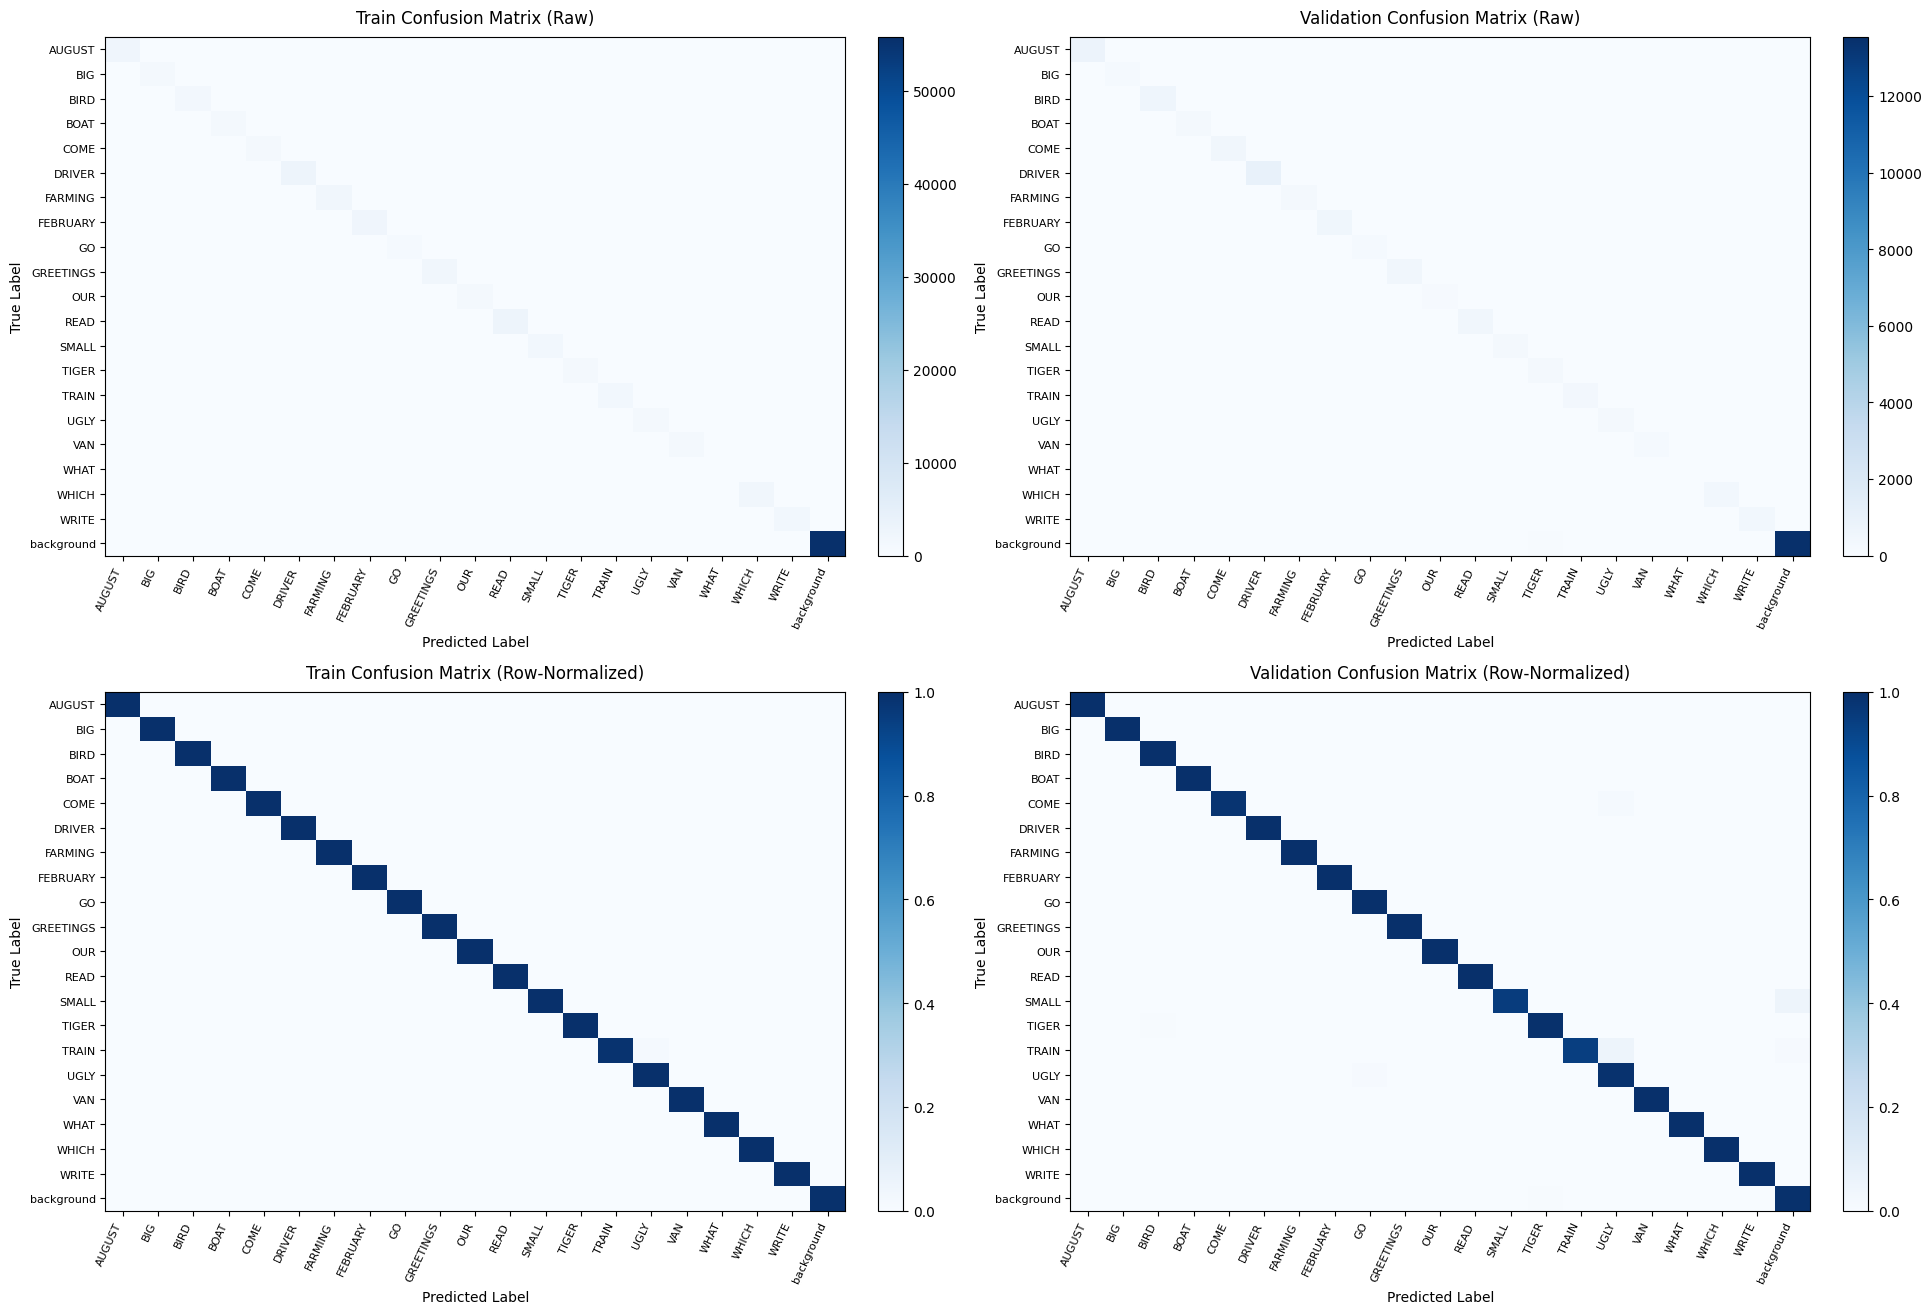

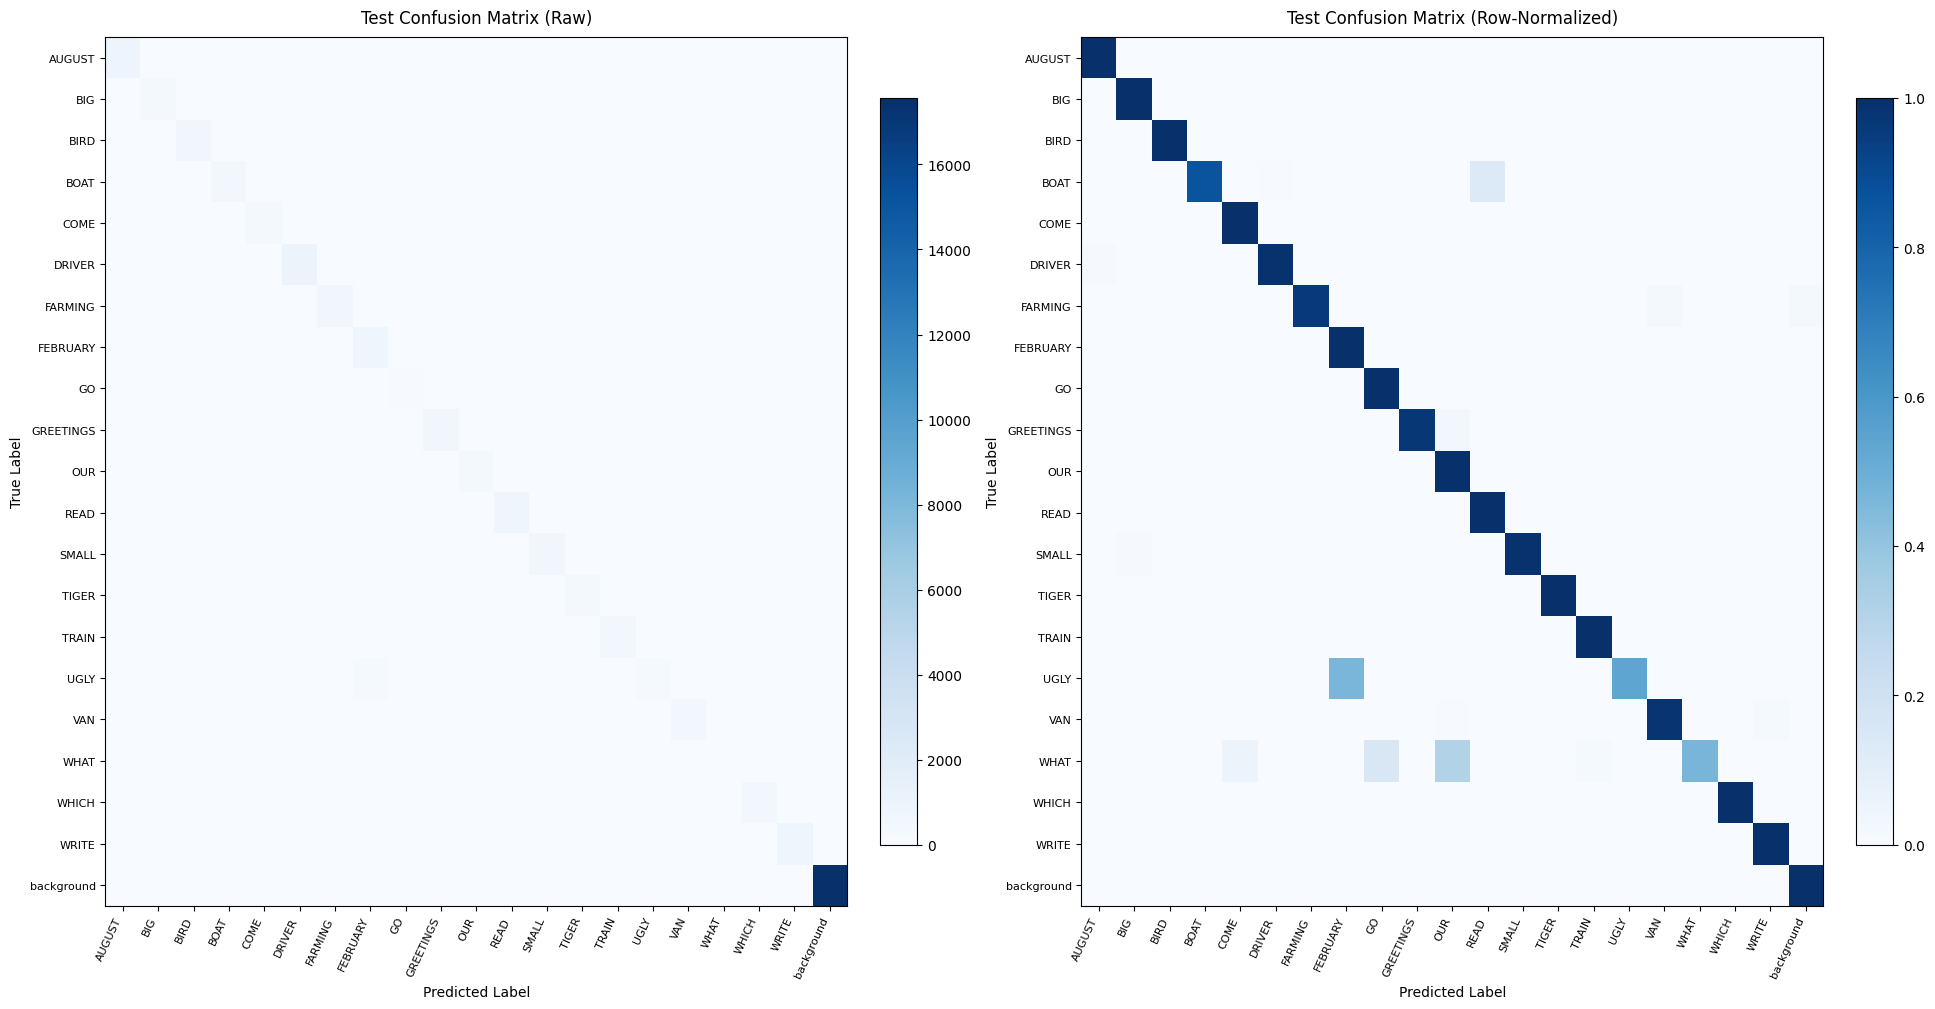


--- Top 5 Misclassifications for Train (True → Predicted) ---
  background → TIGER : 115 times
  background → GO : 73 times
  background → BIG : 46 times
  background → SMALL : 45 times
  TRAIN → UGLY : 20 times

--- Top 5 Misclassifications for Dev Validation (True → Predicted) ---
  background → TIGER : 64 times
  background → BIG : 19 times
  TRAIN → UGLY : 18 times
  SMALL → background : 14 times
  COME → UGLY : 6 times

--- Top 5 Misclassifications for Test (True → Predicted) ---
  UGLY → FEBRUARY : 208 times
  BOAT → READ : 66 times
  background → TIGER : 31 times
  WHAT → OUR : 23 times
  GREETINGS → OUR : 17 times


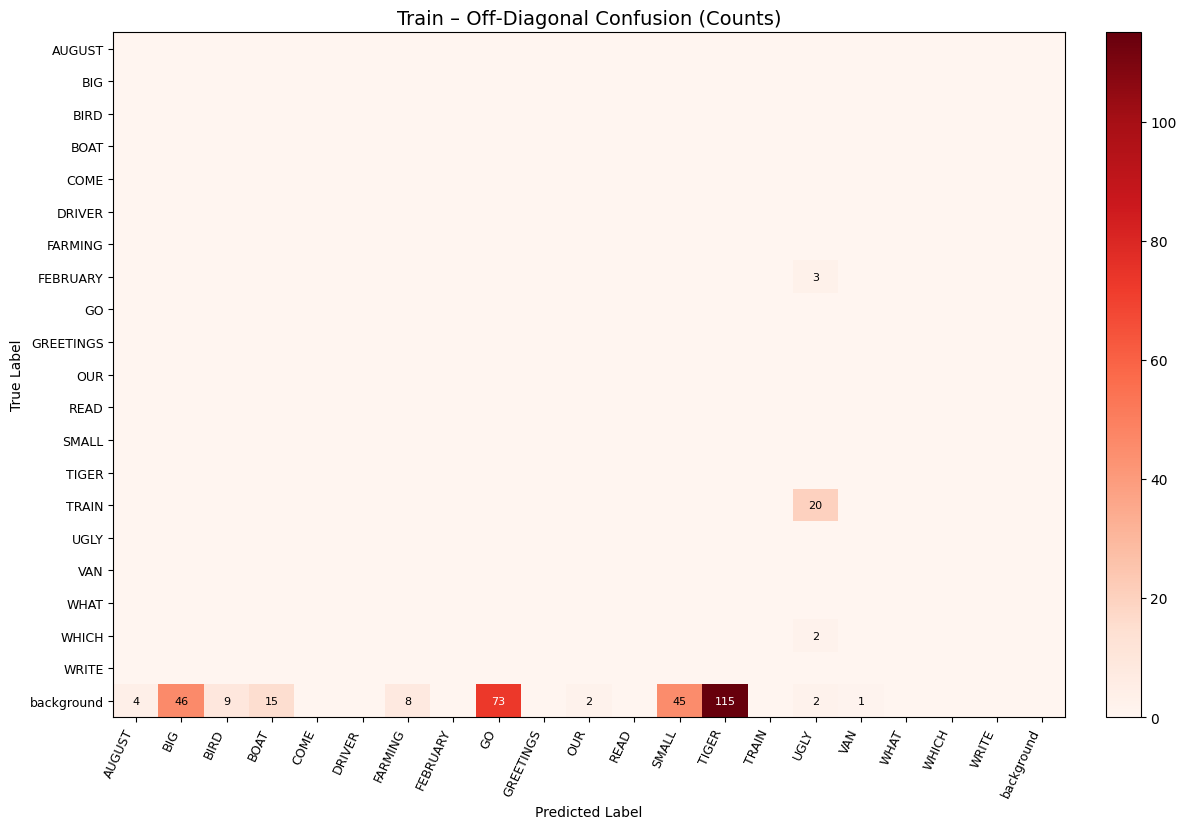

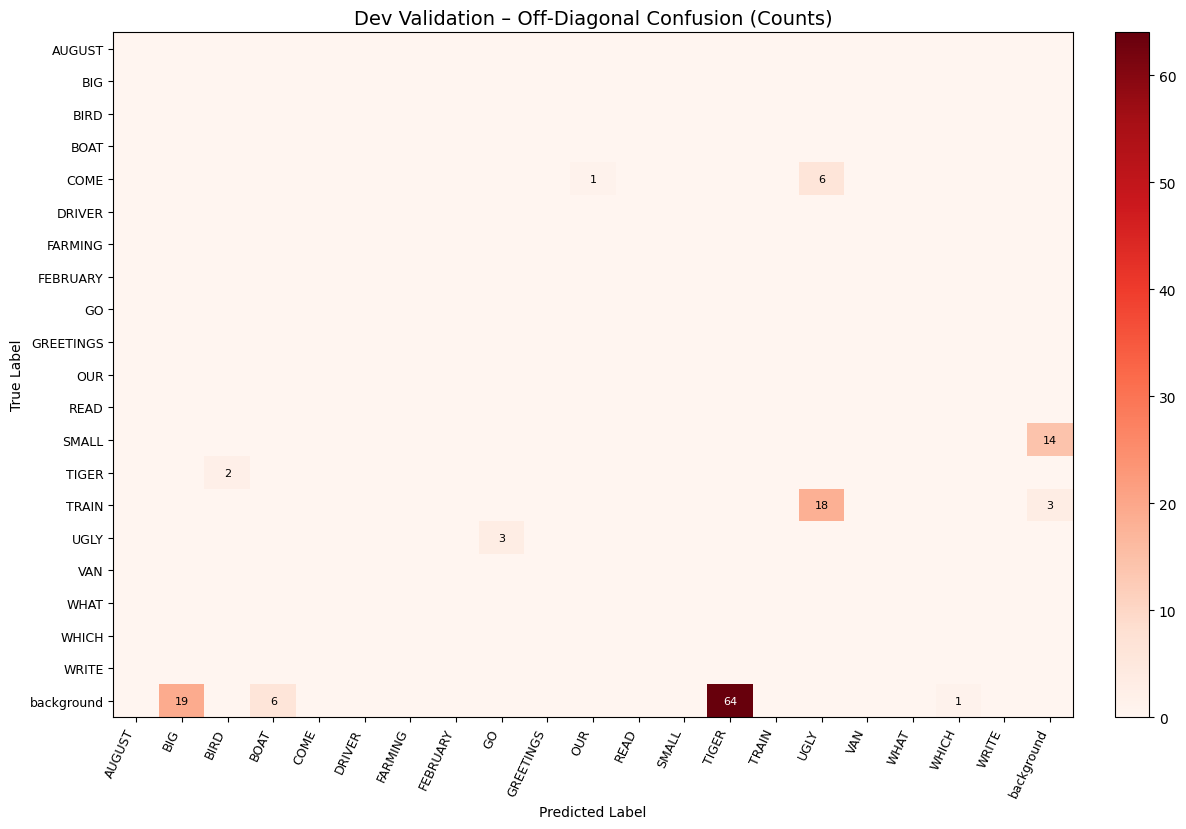

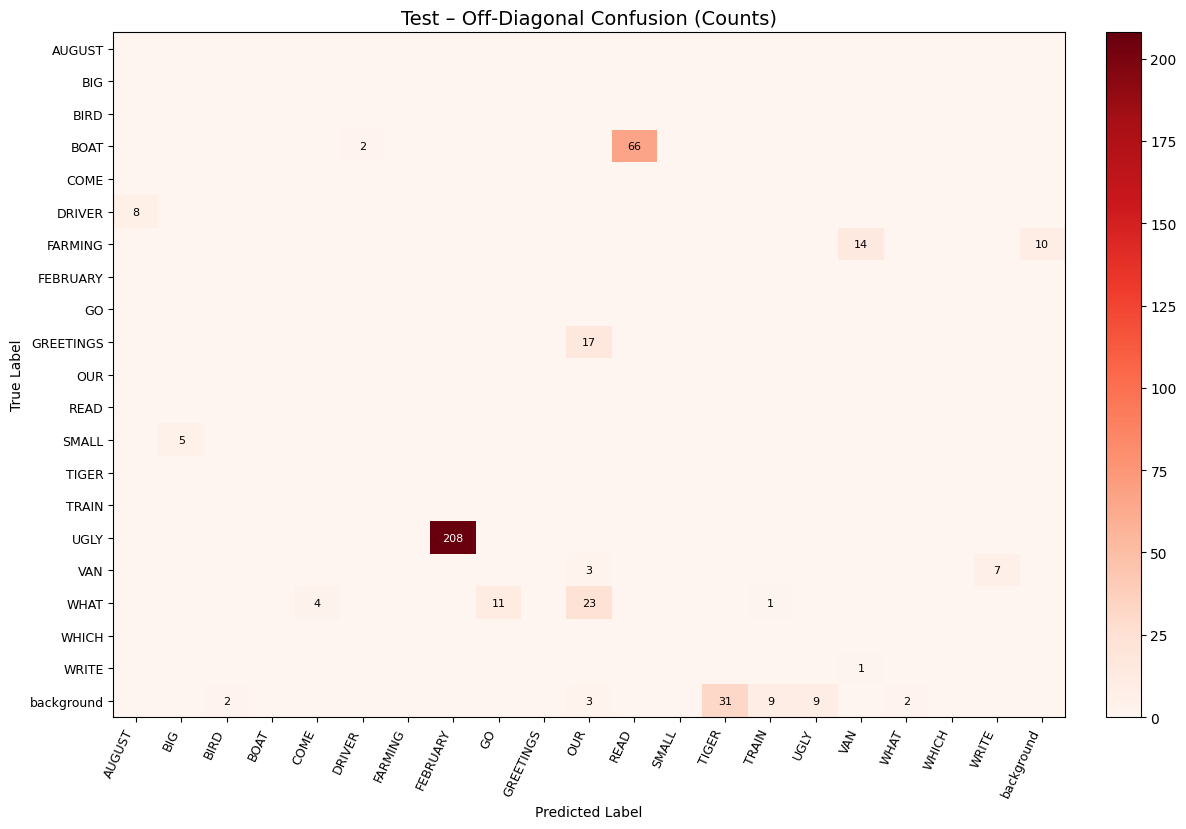

In [16]:
def evaluate_and_report_split(model_obj: nn.Module, split_name: str, loader: DataLoader, id_to_label: dict[int, str]):
    """Evaluate one split and print accuracy, macro-F1, confusion matrix, and classification report."""
    acc, preds, targets = evaluate_model(model_obj, loader)
    print(f"{split_name} Accuracy: {acc:.4f}")

    if len(targets) == 0:
        print(f"{split_name} set is empty; confusion matrix/report are skipped.")
        return acc, float("nan"), preds, targets, None

    target_names = [id_to_label[i] for i in range(len(id_to_label))]
    labels = list(range(len(target_names)))

    cm = confusion_matrix(targets, preds, labels=labels)
    print(f"{split_name} Confusion Matrix:")
    print(cm)

    report_text = classification_report(
        targets, preds, labels=labels, target_names=target_names, zero_division=0
    )
    report_dict = classification_report(
        targets, preds, labels=labels, target_names=target_names, zero_division=0, output_dict=True
    )
    macro_f1 = float(report_dict.get("macro avg", {}).get("f1-score", 0.0))

    print(f"\n{split_name} Macro-F1: {macro_f1:.4f}")
    print(f"\n{split_name} Classification Report:")
    print(report_text)

    return acc, macro_f1, preds, targets, cm


def _short_labels(names: list[str], max_len: int = 18) -> list[str]:
    out = []
    for name in names:
        s = str(name)
        if len(s) <= max_len:
            out.append(s)
        else:
            out.append(s[: max_len - 3] + "...")
    return out


def _draw_confusion(ax, cm: np.ndarray, labels: list[str], title: str, normalize: bool = False):
    if cm is None:
        ax.axis("off")
        ax.set_title(f"{title} (unavailable)")
        return

    cm_float = cm.astype(np.float32)
    if normalize:
        row_sum = cm_float.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_float, np.clip(row_sum, 1.0, None))
        vmin, vmax = 0.0, 1.0
        value_fmt = "{:.2f}"
    else:
        cm_plot = cm_float
        vmin, vmax = 0.0, None
        value_fmt = "{:.0f}"

    im = ax.imshow(cm_plot, interpolation="nearest", cmap="Blues", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=12, pad=10)
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(labels))
    display_labels = _short_labels(labels, max_len=18)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(display_labels, rotation=65, ha="right", fontsize=8)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(display_labels, fontsize=8)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

    if len(labels) <= 18:
        threshold = cm_plot.max() * 0.5 if cm_plot.size > 0 else 0.0
        for i in range(cm_plot.shape[0]):
            for j in range(cm_plot.shape[1]):
                val = cm_plot[i, j]
                text_color = "white" if val > threshold else "black"
                ax.text(j, i, value_fmt.format(val), ha="center", va="center", fontsize=7, color=text_color)

    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_ylim(len(labels) - 0.5, -0.5)


def plot_confusion_matrices(train_cm: np.ndarray | None, val_cm: np.ndarray | None, target_names: list[str], test_cm: np.ndarray | None = None):
    """Plot raw and row-normalized confusion matrices."""
    n_classes = len(target_names)
    fig_w = max(16, min(36, 10 + 0.45 * n_classes))
    fig_h = max(10, min(24, 8 + 0.25 * n_classes))
    fig, axes = plt.subplots(2, 2, figsize=(fig_w, fig_h))

    _draw_confusion(axes[0, 0], train_cm, target_names, "Train Confusion Matrix (Raw)", normalize=False)
    _draw_confusion(axes[0, 1], val_cm, target_names, "Validation Confusion Matrix (Raw)", normalize=False)
    _draw_confusion(axes[1, 0], train_cm, target_names, "Train Confusion Matrix (Row-Normalized)", normalize=True)
    _draw_confusion(axes[1, 1], val_cm, target_names, "Validation Confusion Matrix (Row-Normalized)", normalize=True)

    plt.tight_layout()
    plt.show()

    if test_cm is not None:
        fig_w = max(16, min(36, 10 + 0.45 * n_classes))
        fig_h = max(8, min(16, 6 + 0.2 * n_classes))
        fig2, axes2 = plt.subplots(1, 2, figsize=(fig_w, fig_h))
        _draw_confusion(axes2[0], test_cm, target_names, "Test Confusion Matrix (Raw)", normalize=False)
        _draw_confusion(axes2[1], test_cm, target_names, "Test Confusion Matrix (Row-Normalized)", normalize=True)
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# NEW FUNCTIONS: Misclassification analysis
# ------------------------------------------------------------
def summarize_confusions(cm: np.ndarray, target_names: list[str], top_k: int = 5, split_name: str = ""):
    """Print the most frequent false positive and false negative pairs."""
    if cm is None or cm.size == 0:
        print(f"No confusion matrix for {split_name}.")
        return

    n = len(target_names)
    # Off-diagonal entries only
    fp_counts = []   # (true_class, pred_class, count)
    fn_counts = []   # (true_class, pred_class, count) – same as above, just different perspective
    for i in range(n):
        for j in range(n):
            if i != j and cm[i, j] > 0:
                fp_counts.append((target_names[i], target_names[j], cm[i, j]))
                fn_counts.append((target_names[i], target_names[j], cm[i, j]))

    fp_counts.sort(key=lambda x: x[2], reverse=True)
    fn_counts.sort(key=lambda x: x[2], reverse=True)

    print(f"\n--- Top {top_k} Misclassifications for {split_name} (True → Predicted) ---")
    if fp_counts:
        for true, pred, count in fp_counts[:top_k]:
            print(f"  {true} → {pred} : {count} times")
    else:
        print("  No misclassifications.")


def plot_misclassification_heatmap(cm: np.ndarray, target_names: list[str], split_name: str):
    """
    Plot a heatmap where diagonal is set to zero to highlight off-diagonal confusion.
    Each cell shows the count of true class i predicted as class j (i != j).
    """
    if cm is None:
        print(f"Skipping misclassification heatmap for {split_name} (no data).")
        return

    # Zero out the diagonal
    cm_off = cm.copy().astype(float)
    np.fill_diagonal(cm_off, 0)

    # If everything is zero, skip
    if np.sum(cm_off) == 0:
        print(f"No misclassifications to show for {split_name}.")
        return

    fig, ax = plt.subplots(figsize=(max(12, 0.5 * len(target_names)), max(8, 0.4 * len(target_names))))
    im = ax.imshow(cm_off, interpolation="nearest", cmap="Reds", aspect="auto")
    ax.set_title(f"{split_name} – Off‑Diagonal Confusion (Counts)", fontsize=14)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(target_names))
    display_labels = _short_labels(target_names, max_len=18)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(display_labels, rotation=65, ha="right", fontsize=9)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(display_labels, fontsize=9)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    # Annotate cells with values
    threshold = cm_off.max() * 0.5 if cm_off.size > 0 else 0.0
    for i in range(cm_off.shape[0]):
        for j in range(cm_off.shape[1]):
            val = cm_off[i, j]
            if val > 0:
                text_color = "white" if val > threshold else "black"
                ax.text(j, i, int(val), ha="center", va="center", fontsize=8, color=text_color)

    ax.set_xlim(-0.5, len(target_names) - 0.5)
    ax.set_ylim(len(target_names) - 0.5, -0.5)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main evaluation execution (modified to include new analysis)
# ------------------------------------------------------------
# Rebuild loaders for deterministic evaluation pass.
best_loaders = build_palmref_loaders(seed_offset=999)

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Detailed reports for model: {MODEL_NAME} (normalization={NORMALIZATION_NAME})")
train_acc_eval, train_macro_f1_eval, train_preds_eval, train_targets_eval, train_cm = evaluate_and_report_split(
    model_obj=model,
    split_name="Train",
    loader=best_loaders["train_eval_loader"],
    id_to_label=id_to_label,
)
print()
val_acc_eval, val_macro_f1_eval, val_preds_eval, val_targets_eval, val_cm = evaluate_and_report_split(
    model_obj=model,
    split_name="Dev Validation",
    loader=best_loaders["val_loader"],
    id_to_label=id_to_label,
)
print()
test_acc_eval, test_macro_f1_eval, test_preds_eval, test_targets_eval, test_cm = evaluate_and_report_split(
    model_obj=model,
    split_name="Test (user3)",
    loader=best_loaders["test_loader"],
    id_to_label=id_to_label,
)

# One-row evaluation summary table.
eval_comparison_df = pd.DataFrame([
    {
        "model_name": MODEL_NAME,
        "normalization": NORMALIZATION_NAME,
        "train_acc": float(train_acc_eval),
        "train_macro_f1": float(train_macro_f1_eval),
        "val_acc": float(val_acc_eval),
        "val_macro_f1": float(val_macro_f1_eval),
        "test_acc": float(test_acc_eval),
        "test_macro_f1": float(test_macro_f1_eval),
    }
])
print("\n========== EVALUATION SUMMARY (CLIP-LEVEL) ==========")
display(eval_comparison_df)

target_names = [id_to_label[i] for i in range(len(id_to_label))]

# Original confusion matrix plots (raw + normalized)
if train_cm is not None or val_cm is not None:
    plot_confusion_matrices(train_cm=train_cm, val_cm=val_cm, test_cm=test_cm, target_names=target_names)

# NEW: Print top misclassifications
if train_cm is not None:
    summarize_confusions(train_cm, target_names, top_k=5, split_name="Train")
if val_cm is not None:
    summarize_confusions(val_cm, target_names, top_k=5, split_name="Dev Validation")
if test_cm is not None:
    summarize_confusions(test_cm, target_names, top_k=5, split_name="Test")

# NEW: Plot off‑diagonal heatmaps (false positives/negatives visualized)
if train_cm is not None:
    plot_misclassification_heatmap(train_cm, target_names, split_name="Train")
if val_cm is not None:
    plot_misclassification_heatmap(val_cm, target_names, split_name="Dev Validation")
if test_cm is not None:
    plot_misclassification_heatmap(test_cm, target_names, split_name="Test")


## 14) Training Curves

We visualize training loss plus train/validation accuracy to inspect learning dynamics.

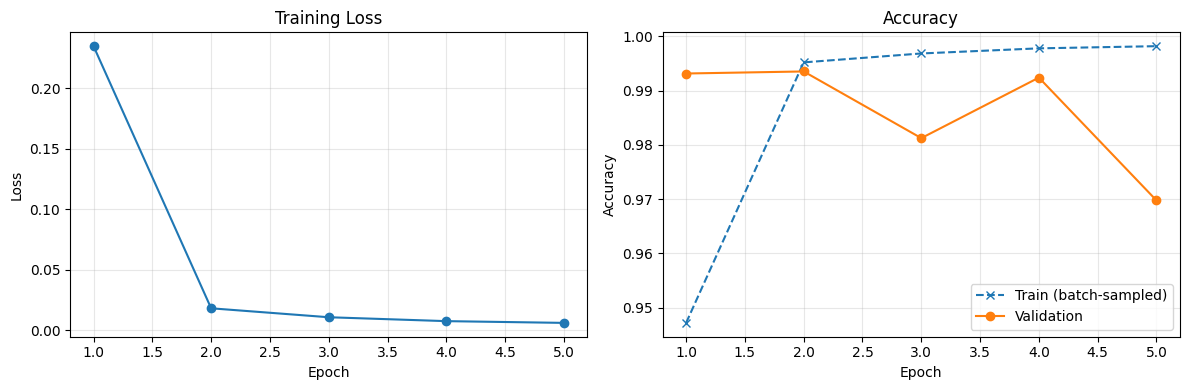

In [17]:
epochs_axis = np.arange(1, len(history_train_loss) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, history_train_loss, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# plt.plot(epochs_axis, history_train_acc, marker="o", label="Train (full eval)")
if "history_train_batch_acc" in globals() and len(history_train_batch_acc) == len(epochs_axis):
    plt.plot(epochs_axis, history_train_batch_acc, marker="x", linestyle="--", label="Train (batch-sampled)")
plt.plot(epochs_axis, history_val_acc, marker="o", label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15) Debug Summary

This final summary prints key counts required for troubleshooting and reproducibility checks.

In [18]:
raw_segment_count = len([s for segs in segments_by_user.values() for s in segs])
dev_raw_segment_count = len([s for segs in dev_segments_all.values() for s in segs])
test_raw_segment_count = len(filtered_test_segments)
filtered_dev_segment_count = len(filtered_train_segments) + len(filtered_val_segments)
window_count = len(X_train) + len(X_val) + len(X_test)

print("========== DEBUG SUMMARY ==========")
print(f"Raw segments (all recordings)         : {raw_segment_count}")
print(f"Raw segments (dev users, filtered)    : {dev_raw_segment_count}")
print(f"Raw segments (test user, filtered)    : {test_raw_segment_count}")
print(f"Segments after filtering (dev train+val): {filtered_dev_segment_count}")
print(f"  dev train segments                  : {len(filtered_train_segments)}")
print(f"  dev val segments                    : {len(filtered_val_segments)}")
print(f"  test segments                       : {len(filtered_test_segments)}")
print(f"Dev train recordings                  : {len(dev_train_recording_keys)}")
print(f"Dev val recordings                    : {len(dev_val_recording_keys)}")
print(f"Total windows (train + val + test)    : {window_count}")
print(f"Train windows                         : {len(X_train)}")
print(f"Validation windows                    : {len(X_val)}")
print(f"Test windows                          : {len(X_test)}")
print(f"Num classes (train labels)            : {len(label_to_id)}")
print("Class distribution (train windows):")
print(Counter(y_train.tolist()))
print("Class distribution (val windows):")
print(Counter(y_val.tolist()))
print("Class distribution (test windows):")
print(Counter(y_test.tolist()))


========== DEBUG SUMMARY ==========
Raw segments (all recordings)         : 2293
Raw segments (dev users, filtered)    : 1830
Raw segments (test user, filtered)    : 457
Segments after filtering (dev train+val): 1830
  dev train segments                  : 1467
  dev val segments                    : 363
  test segments                       : 457
Dev train recordings                  : 177
Dev val recordings                    : 44
Total windows (train + val + test)    : 136258
Train windows                         : 87067
Validation windows                    : 21166
Test windows                          : 28025
Num classes (train labels)            : 21
Class distribution (train windows):
Counter({20: 56110, 11: 2803, 5: 2631, 7: 2358, 0: 2219, 18: 1875, 9: 1851, 6: 1830, 14: 1694, 12: 1656, 19: 1598, 2: 1468, 15: 1261, 1: 1236, 16: 1194, 3: 1155, 4: 1148, 13: 1078, 10: 970, 8: 785, 17: 147})
Class distribution (val windows):
Counter({20: 13631, 5: 979, 0: 779, 2: 631, 7: 506, 11: 4

## 16) Streaming Online Inference + WER 

This section runs **frame-by-frame streaming inference** for the trained model and computes sequence-level WER.

Split policy for WER:
- **Test** (`user3`, lockbox): primary generalization metric (all test recordings with gloss GT)
- **Dev val** (`user1`/`user2` val recordings): in-domain sequence decoding sanity check
- **Dev train** (optional, commented out): slow; uncomment to benchmark training recordings

Streaming mode:
- **Left causal**: left-aligned windows with no future context

Post-processing: rolling buffer, confidence gating, causal majority voting, transition emission, sequence-level WER.


In [19]:
# model.load_state_dict(torch.load("/kaggle/input/datasets/shoabahamed/sign-language-thesis/transformer_users3.pt", weights_only=True)['model_state_dict'])

In [20]:
# ---------------------------------------------------------------------------
# Low-level inference — returns RAW LOGITS (not softmax)
# ---------------------------------------------------------------------------

def _predict_window_logits(
    model_obj: nn.Module,
    window: np.ndarray,
    device: torch.device = DEVICE,
) -> np.ndarray:
    """
    Forward pass for one normalized window.

    Input  : window  (W, D)
    Output : logits  (C,)  — raw pre-softmax scores
    """
    model_obj.eval()
    x       = torch.tensor(window, dtype=torch.float32, device=device).unsqueeze(0)
    lengths = torch.tensor([window.shape[0]], dtype=torch.long, device=device)

    with torch.no_grad():
        logits = model_obj(x, lengths)
        if logits.ndim == 1:
            logits = logits.unsqueeze(0)

    return logits[0].detach().cpu().numpy().astype(np.float32)


# ---------------------------------------------------------------------------
# Bag aggregator
# ---------------------------------------------------------------------------

class _BagAggregator:
    """
    Causal sliding bag over raw logits.

    Why logits and not probs:
        Averaging in logit space is equivalent to a product-of-experts,
        which is sharper and more discriminative than averaging softmax probs.
        Converting to probs happens once after aggregation.

    Modes
    -----
    mean      : arithmetic mean of per-window probs after softmax
    max       : element-wise max of per-window probs
    attention : recency-weighted mean, most recent window weighted highest
    """

    def __init__(self, bag_size: int, aggregation: str, num_classes: int):
        self.bag_size    = max(1, int(bag_size))
        self.aggregation = aggregation
        self.num_classes = num_classes
        self._buffer     = deque(maxlen=self.bag_size)

    def update(self, logits: np.ndarray) -> np.ndarray | None:
        """
        Push one logit vector and return aggregated probs.

        Returns None until bag is full (first bag_size frames are skipped).
        """
        self._buffer.append(logits.copy())

        if len(self._buffer) < self.bag_size:
            return None

        bag = np.stack(self._buffer, axis=0)  # (bag_size, C)

        # Numerically stable softmax per row
        bag_shifted = bag - bag.max(axis=-1, keepdims=True)
        exp_bag     = np.exp(bag_shifted)
        probs       = exp_bag / exp_bag.sum(axis=-1, keepdims=True)  # (bag_size, C)

        if self.aggregation == "mean":
            return probs.mean(axis=0)

        elif self.aggregation == "max":
            return probs.max(axis=0)

        elif self.aggregation == "attention":
            weights = np.linspace(0.5, 1.0, len(self._buffer))
            weights /= weights.sum()
            return (probs * weights[:, np.newaxis]).sum(axis=0)

        else:
            raise ValueError(f"Unknown aggregation mode: {self.aggregation}")

    def reset(self):
        self._buffer.clear()


# ---------------------------------------------------------------------------
# Simplified streaming decoder
# ---------------------------------------------------------------------------

class SimplifiedBagDecoder:
    """
    Causal streaming decoder using bag-aggregated logits.

    States
    ------
    SEEKING : waiting for a sign to begin
    IN_SIGN : inside an active sign region, accumulating votes

    Emission
    --------
    Fires at the TRAILING edge when the bag transitions to background.
    Emits the majority label observed across the entire region.
    Discards regions shorter than min_sign_frames (noise / glitches).

    Storage additions
    -----------------
    pre_bag_logits  : raw logits from model before bag smoothing, stored per step
    post_bag_probs  : aggregated probability vector after bag smoothing, stored per step
    emit_region     : (start_frame, end_frame, label) tuple on emission, else None
    region_start_frame : tracks frame index where current IN_SIGN region began
    """

    def __init__(
        self,
        id_to_label: dict[int, str],
        background_label: str,
        bag_size: int               = BAG_SIZE,
        aggregation: str            = BAG_AGGREGATION,
        confidence_threshold: float = CONFIDENCE_THRESHOLD,
        sign_bg_margin: float       = SIGN_BG_MARGIN,
        min_sign_frames: int        = MIN_SIGN_FRAMES,
    ):
        self.id_to_label          = id_to_label
        self.background_label     = background_label
        self.confidence_threshold = float(confidence_threshold)
        self.sign_bg_margin       = float(sign_bg_margin)
        self.min_sign_frames      = max(1, int(min_sign_frames))

        self.background_id = next(
            (k for k, v in id_to_label.items() if v == background_label),
            None,
        )

        num_classes  = len(id_to_label)
        self._bag    = _BagAggregator(bag_size, aggregation, num_classes)

        # Hysteresis state
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None   # frame index where current IN_SIGN region began

    # ------------------------------------------------------------------

    def _gate(self, agg_probs: np.ndarray):
        """
        Apply confidence gate to aggregated probabilities.

        Returns
        -------
        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs
        agg_probs is passed through so callers can store it as post_bag_probs.
        """
        pred_id    = int(np.argmax(agg_probs))
        pred_label = self.id_to_label.get(pred_id, f"sign_{pred_id}")
        pred_conf  = float(agg_probs[pred_id])
        bg_conf    = (
            float(agg_probs[self.background_id])
            if self.background_id is not None
            else 0.0
        )

        is_sign = (
            pred_label != self.background_label
            and pred_conf  >= self.confidence_threshold
            and (pred_conf - bg_conf) >= self.sign_bg_margin
        )

        voted_label   = pred_label if is_sign else self.background_label
        is_background = not is_sign

        return voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs

    # ------------------------------------------------------------------

    def update(self, logits: np.ndarray, frame_index: int) -> dict:
        """
        Process one frame.

        Parameters
        ----------
        logits      : (C,) raw logits from model — stored as pre_bag_logits
        frame_index : int current frame index, needed for emit_region tracking

        Returns
        -------
        dict containing:
            raw_label      : top-1 label from pre-bag window logits
            raw_conf       : top-1 confidence from pre-bag window logits
            bg_conf        : background confidence from post-bag probs
            gated_label    : label after confidence gate (post-bag)
            voted_label    : same as gated_label
            state          : decoder state after this step (SEEKING / IN_SIGN)
            emitted_label  : emitted sign label if trailing edge fired, else None
            emit_region    : (start_frame, end_frame, label) on emission, else None
            pre_bag_logits : (C,) raw logits before bag — for visualization
            post_bag_probs : (C,) aggregated probs after bag — for visualization
                             None until bag is full
        """
        pre_bag_logits = logits.copy()          # store raw pre-bag logits
        agg_probs      = self._bag.update(logits)

        # Bag not full yet — stay in SEEKING, emit nothing
        if agg_probs is None:
            raw_probs = np.exp(logits - logits.max())
            raw_probs /= raw_probs.sum()
            return {
                "raw_label":      self.id_to_label.get(int(np.argmax(logits)), "?"),
                "raw_conf":       float(raw_probs.max()),
                "bg_conf":        0.0,
                "gated_label":    self.background_label,
                "voted_label":    self.background_label,
                "state":          self.state,
                "emitted_label":  None,
                "emit_region":    None,
                "pre_bag_logits": pre_bag_logits,
                "post_bag_probs": None,
            }

        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs = \
            self._gate(agg_probs)

        emitted_label = None
        emit_region   = None

        if self.state == "SEEKING":
            if not is_background:
                # Confirmed sign onset — enter region
                self.state              = "IN_SIGN"
                self.region_votes[voted_label] += 1
                self.sign_frames        = 1
                self.region_start_frame = frame_index   # record region start

        elif self.state == "IN_SIGN":
            if not is_background:
                self.region_votes[voted_label] += 1
                self.sign_frames += 1
            else:
                # Bag has confirmed background — trailing edge reached
                if self.sign_frames >= self.min_sign_frames:
                    emitted_label = self.region_votes.most_common(1)[0][0]
                    emit_region   = (
                        self.region_start_frame,    # start frame of region
                        frame_index,                # end frame of region (trailing edge)
                        emitted_label,
                    )
                # else: region too short → discard silently

                self.state              = "SEEKING"
                self.region_votes       = Counter()
                self.sign_frames        = 0
                self.region_start_frame = None      # reset region start

        return {
            "raw_label":      pred_label,
            "raw_conf":       pred_conf,
            "bg_conf":        bg_conf,
            "gated_label":    voted_label,
            "voted_label":    voted_label,
            "state":          self.state,
            "emitted_label":  emitted_label,
            "emit_region":    emit_region,          # (start, end, label) or None
            "pre_bag_logits": pre_bag_logits,       # (C,) raw pre-bag logits
            "post_bag_probs": agg_probs,            # (C,) post-bag aggregated probs
        }

    # ------------------------------------------------------------------

    def flush(self) -> tuple[str | None, tuple | None]:
        """
        Call once after all frames are processed.

        Emits any sign region still open at sequence end.
        Necessary when a sequence ends without returning to background.

        Returns
        -------
        (emitted_label, emit_region) where emit_region is
        (start_frame, None, label) — None end means sequence end;
        caller should fill with T-1.
        """
        emitted     = None
        emit_region = None

        if self.state == "IN_SIGN" and self.sign_frames >= self.min_sign_frames:
            emitted     = self.region_votes.most_common(1)[0][0]
            emit_region = (
                self.region_start_frame,
                None,       # end frame unknown here — filled by caller with T-1
                emitted,
            )

        # Always reset — decoder is invalid after flush
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None
        self._bag.reset()

        return emitted, emit_region


# ---------------------------------------------------------------------------
# Streaming inference loop
# ---------------------------------------------------------------------------

def _stream_predict_left_causal(
    V: np.ndarray,
    model_obj: nn.Module,
    window_size: int,
    stride: int,
    normalize_fn,
    id_to_label: dict[int, str],
    background_label: str,
    bag_size: int,
    aggregation: str,
    confidence_threshold: float,
    sign_bg_margin: float,
    min_sign_frames: int,
) -> tuple[list[dict], int]:
    """
    Left-causal streaming inference with bag-aggregated decoder.

    Input  : V  (T, D)
    Output : stream_steps  list of per-step dicts
             delay_frames  int (0 for left-causal)

    Each step dict now includes:
        pre_bag_logits : (C,) raw model logits before bag smoothing
        post_bag_probs : (C,) aggregated probs after bag, None until bag full
        emit_region    : (start_frame, end_frame, label) on emission, else None
    """
    if V.ndim != 2:
        raise ValueError(f"Expected (T, D), got {V.shape}")

    T = V.shape[0]
    if T == 0:
        return [], 0

    decoder = SimplifiedBagDecoder(
        id_to_label=id_to_label,
        background_label=background_label,
        bag_size=bag_size,
        aggregation=aggregation,
        confidence_threshold=confidence_threshold,
        sign_bg_margin=sign_bg_margin,
        min_sign_frames=min_sign_frames,
    )

    frame_buffer = deque(maxlen=window_size)
    stream_steps = []

    for frame_idx in range(T):
        frame_buffer.append(V[frame_idx].astype(np.float32, copy=False))

        # Wait until window is full
        if len(frame_buffer) < window_size:
            continue

        # Respect stride
        if ((frame_idx - (window_size - 1)) % stride) != 0:
            continue

        window   = np.stack(frame_buffer, axis=0).astype(np.float32, copy=False)
        norm_win = normalize_fn(window)
        logits   = _predict_window_logits(model_obj, norm_win)  # raw pre-bag logits

        decoded  = decoder.update(logits, frame_index=frame_idx)  # pass frame_index

        decoded.update({
            "frame_index":  int(frame_idx),
            "window_start": int(frame_idx - window_size + 1),
            "window_end":   int(frame_idx),
        })
        stream_steps.append(decoded)

    # Flush: emit any sign still open at sequence end
    final_emission, final_emit_region = decoder.flush()     # unpack tuple

    if final_emission is not None:
        # Fill in the end frame (None from flush → T-1)
        if final_emit_region is not None:
            final_emit_region = (
                final_emit_region[0],
                T - 1,
                final_emit_region[2],
            )
        last = stream_steps[-1] if stream_steps else {}
        stream_steps.append({
            "raw_label":      final_emission,
            "raw_conf":       1.0,
            "bg_conf":        0.0,
            "gated_label":    final_emission,
            "voted_label":    final_emission,
            "state":          "FLUSH",
            "emitted_label":  final_emission,
            "emit_region":    final_emit_region,    # (start, T-1, label)
            "pre_bag_logits": None,                 # no new window at flush
            "post_bag_probs": None,
            "frame_index":    T - 1,
            "window_start":   last.get("window_start", T - window_size),
            "window_end":     T - 1,
        })

    return stream_steps, 0


def stream_online_predict(
    V: np.ndarray,
    model_obj: nn.Module,
    window_size: int,
    stride: int,
    normalize_fn,
    id_to_label: dict[int, str],
    background_label: str,
    bag_size: int               = BAG_SIZE,
    aggregation: str            = BAG_AGGREGATION,
    confidence_threshold: float = CONFIDENCE_THRESHOLD,
    sign_bg_margin: float       = SIGN_BG_MARGIN,
    min_sign_frames: int        = MIN_SIGN_FRAMES,
    stream_mode: str            = STREAM_MODE,
) -> tuple[list[dict], int]:

    if stream_mode != "left_causal":
        raise ValueError(f"Unsupported stream_mode '{stream_mode}'")

    return _stream_predict_left_causal(
        V=V,
        model_obj=model_obj,
        window_size=window_size,
        stride=stride,
        normalize_fn=normalize_fn,
        id_to_label=id_to_label,
        background_label=background_label,
        bag_size=bag_size,
        aggregation=aggregation,
        confidence_threshold=confidence_threshold,
        sign_bg_margin=sign_bg_margin,
        min_sign_frames=min_sign_frames,
    )


# ---------------------------------------------------------------------------
# WER helpers — unchanged
# ---------------------------------------------------------------------------

def remove_consecutive_duplicates(labels: list[str]) -> list[str]:
    if not labels:
        return []
    out = [labels[0]]
    for lbl in labels[1:]:
        if lbl != out[-1]:
            out.append(lbl)
    return out


def remove_background(
    labels: list[str],
    background_label: str = BACKGROUND_LABEL,
) -> list[str]:
    return [lbl for lbl in labels if lbl != background_label]


def compute_wer(pred: list[str], gt: list[str]) -> float:
    n, m = len(gt), len(pred)
    if n == 0:
        return 0.0 if m == 0 else 1.0

    dp = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(1, n + 1):
        dp[i, 0] = i
    for j in range(1, m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost      = 0 if gt[i - 1] == pred[j - 1] else 1
            dp[i, j]  = min(dp[i-1, j] + 1, dp[i, j-1] + 1, dp[i-1, j-1] + cost)

    return float(dp[n, m] / n)


# ---------------------------------------------------------------------------
# Per-sequence inference + WER
# ---------------------------------------------------------------------------

def online_inference_and_wer(
    V: np.ndarray,
    model_obj: nn.Module,
    ground_truth: list[str],
    W: int,
    S: int,
    id_to_label: dict[int, str],
    background_label: str        = BACKGROUND_LABEL,
    normalize_fn                 = palm_reference_normalize_sequence,
    stream_mode: str             = STREAM_MODE,
    bag_size: int                = BAG_SIZE,
    aggregation: str             = BAG_AGGREGATION,
    confidence_threshold: float  = CONFIDENCE_THRESHOLD,
    sign_bg_margin: float        = SIGN_BG_MARGIN,
    min_sign_frames: int         = MIN_SIGN_FRAMES,
    gt_segments: list            = None,    # sample["segmentation_regions"] passed in from caller
) -> dict:
    """
    Full streaming inference pipeline + WER for one sequence.

    Returns
    -------
    dict including:
        emit_regions : list of (start_frame, end_frame, label) — predicted sign regions
        gt_segments  : list of segmentation regions from ground truth data
                       passed through from sample["segmentation_regions"]
    """
    stream_steps, delay_frames = stream_online_predict(
        V=V,
        model_obj=model_obj,
        window_size=W,
        stride=S,
        normalize_fn=normalize_fn,
        id_to_label=id_to_label,
        background_label=background_label,
        bag_size=bag_size,
        aggregation=aggregation,
        confidence_threshold=confidence_threshold,
        sign_bg_margin=sign_bg_margin,
        min_sign_frames=min_sign_frames,
        stream_mode=stream_mode,
    )

    emitted_preds = [
        step["emitted_label"]
        for step in stream_steps
        if step["emitted_label"] is not None
    ]

    # Collect all emit regions — one per emitted sign, in order
    emit_regions = [
        step["emit_region"]
        for step in stream_steps
        if step["emit_region"] is not None
    ]

    final_preds = emitted_preds
    wer         = compute_wer(final_preds, ground_truth)

    return {
        "raw_window_predictions": [s["raw_label"]   for s in stream_steps],
        "raw_confidences":        [float(s["raw_conf"]) for s in stream_steps],
        "voted_predictions":      [s["voted_label"]  for s in stream_steps],
        "final_predictions":      final_preds,
        "ground_truth":           ground_truth,
        "wer":                    wer,
        "stream_steps":           stream_steps,
        "stream_mode":            stream_mode,
        "stream_delay_frames":    int(delay_frames),
        "num_stream_predictions": int(len(stream_steps)),
        "first_prediction_frame": (
            int(stream_steps[0]["frame_index"]) if stream_steps else None
        ),
        "emitted_count":          int(len(emitted_preds)),
        # ----------------------------------------------------------------
        # Visualization extras
        # ----------------------------------------------------------------
        "emit_regions":           emit_regions,         # [(start, end, label), ...]
        "gt_segments":            gt_segments or [],    # from sample["segmentation_regions"]
    }


# ---------------------------------------------------------------------------
# Evaluation harness
# ---------------------------------------------------------------------------

def evaluate_sequence_set_wer(
    samples: list[dict],
    split_name: str,
    model_obj: nn.Module,
    normalize_fn: Callable[[np.ndarray], np.ndarray],
    normalization_name: str,
    print_examples: int         = 2,
    window_size: int            = ONLINE_WINDOW_SIZE,
    stride: int                 = ONLINE_STRIDE,
    stream_mode: str            = STREAM_MODE,
    bag_size: int               = BAG_SIZE,
    aggregation: str            = BAG_AGGREGATION,
    confidence_threshold: float = CONFIDENCE_THRESHOLD,
    sign_bg_margin: float       = SIGN_BG_MARGIN,
    min_sign_frames: int        = MIN_SIGN_FRAMES,
) -> pd.DataFrame:
    """
    Evaluate streaming WER for an entire sequence set.

    Parameters
    ----------
    samples          : list of dicts with keys V, ground_truth, user,
                       recording_id, num_frames, missing_ratio,
                       segmentation_regions (used for GT visualization)
    split_name       : label for printed output
    print_examples   : how many individual results to print
    bag_size         : causal logit bag size
    aggregation      : "mean" | "max" | "attention"
    confidence_threshold : gate threshold on aggregated probs
    sign_bg_margin   : minimum gap between sign prob and background prob
    min_sign_frames  : discard regions shorter than this

    Returns
    -------
    pd.DataFrame — one row per sample.
    stream_steps (with pre_bag_logits, post_bag_probs, emit_region per step)
    and emit_regions / gt_segments are stored in the "stream_steps" and
    "emit_regions" / "gt_segments" columns for downstream visualization.
    """
    rows = []

    for idx, sample in enumerate(samples, start=1):
        result = online_inference_and_wer(
            V=sample["V"],
            model_obj=model_obj,
            ground_truth=sample["ground_truth"],
            W=window_size,
            S=stride,
            id_to_label=id_to_label,
            background_label=BACKGROUND_LABEL,
            normalize_fn=normalize_fn,
            stream_mode=stream_mode,
            bag_size=bag_size,
            aggregation=aggregation,
            confidence_threshold=confidence_threshold,
            sign_bg_margin=sign_bg_margin,
            min_sign_frames=min_sign_frames,
            gt_segments=sample.get("segmentation_regions", []),  # pass GT segments
        )

        rows.append({
            "sample_idx":             idx,
            "split":                  split_name,
            "user":                   sample["user"],
            "recording_id":           sample["recording_id"],
            "num_frames":             sample["num_frames"],
            "missing_ratio":          sample["missing_ratio"],
            "gt_len":                 len(sample["ground_truth"]),
            "pred_len":               len(result["final_predictions"]),
            "raw_len":                len(result["raw_window_predictions"]),
            "wer":                    result["wer"],
            "stream_mode":            result["stream_mode"],
            "stream_delay_frames":    result["stream_delay_frames"],
            "num_stream_predictions": result["num_stream_predictions"],
            "first_prediction_frame": result["first_prediction_frame"],
            "emitted_count":          result["emitted_count"],
            "ground_truth":           " ".join(sample["ground_truth"]),
            "prediction":             " ".join(result["final_predictions"]),
            # ------------------------------------------------------------------
            # Stored for visualization — not used in WER computation
            # stream_steps holds pre_bag_logits / post_bag_probs / emit_region
            # per step; emit_regions and gt_segments are sequence-level lists
            # ------------------------------------------------------------------
            "stream_steps":           result["stream_steps"],
            "emit_regions":           result["emit_regions"],
            "gt_segments":            result["gt_segments"],
        })

    df = pd.DataFrame(rows)
    _print_wer_summary(
        df, split_name, normalization_name, stream_mode, print_examples
    )
    return df


def _print_wer_summary(
    df: pd.DataFrame,
    split_name: str,
    normalization_name: str,
    stream_mode: str,
    print_examples: int,
) -> None:
    header = f"========== {split_name.upper()} WER SUMMARY =========="
    print(f"\n{header}")
    print(f"Normalization  : {normalization_name}")
    print(f"Stream mode    : {stream_mode}")
    print(f"Bag size       : {BAG_SIZE}  ({BAG_SIZE/LEAP_FPS*1000:.0f}ms)")
    print(f"Aggregation    : {BAG_AGGREGATION}")
    print(f"Conf threshold : {CONFIDENCE_THRESHOLD}")
    print(f"Min sign frames: {MIN_SIGN_FRAMES}  ({MIN_SIGN_MS}ms)")
    print(f"Total sequences evaluated: {len(df)}")

    if df.empty:
        return

    print(f"Mean WER:   {df['wer'].mean():.4f}")
    print(f"Median WER: {df['wer'].median():.4f}")
    print(f"Std WER:    {df['wer'].std(ddof=0):.4f}")

    n_show = min(print_examples, len(df))
    print(f"\nShowing {n_show} example sequence(s):")
    for _, row in df.head(n_show).iterrows():
        print(f"  [{int(row['sample_idx'])}] {row['user']} | {row['recording_id']}")
        print(f"    Frames       : {int(row['num_frames'])} | "
              f"Missing ratio: {float(row['missing_ratio']):.3f}")
        print(f"    Stream steps : {int(row['num_stream_predictions'])} | "
              f"Emitted: {int(row['emitted_count'])}")
        print(f"    GT           : {row['ground_truth'].split()}")
        print(f"    Prediction   : {row['prediction'].split()}")
        print(f"    WER          : {float(row['wer']):.4f}")
        if row["emit_regions"]:
            print(f"    Emit regions : {row['emit_regions']}")
        if row["gt_segments"]:
            print(f"    GT segments  : {row['gt_segments']}")


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

if len(test_wer_catalog) == 0:
    raise RuntimeError(
        f"No WER sequences available for test user '{TEST_USER}'."
    )

print("========== ONLINE WER SETUP ==========")
print(f"Model                 : {MODEL_NAME}")
print(f"Normalization         : {NORMALIZATION_NAME}")
print(f"Test sequences        : {len(test_wer_catalog)} ({TEST_USER})")
print(f"Dev val sequences     : {len(dev_val_wer_catalog)}")
print(f"Dev train sequences   : {len(dev_train_wer_catalog)} (WER optional)")
print(f"Printed examples/split: {WER_EXAMPLE_PRINT_COUNT}")
print(f"Stream mode           : {STREAM_MODE}")
print(f"Bag size              : {BAG_SIZE} frames (~{BAG_SIZE/LEAP_FPS*1000:.0f}ms)")
print(f"Aggregation           : {BAG_AGGREGATION}")
print(f"Confidence threshold  : {CONFIDENCE_THRESHOLD}")
print(f"Min sign frames       : {MIN_SIGN_FRAMES} (~{MIN_SIGN_MS}ms)")

test_wer_df = evaluate_sequence_set_wer(
    samples=test_wer_catalog,
    split_name=f"Test ({TEST_USER})",
    model_obj=model,
    normalize_fn=NORMALIZE_FN,
    normalization_name=NORMALIZATION_NAME,
    print_examples=WER_EXAMPLE_PRINT_COUNT,
    stream_mode=STREAM_MODE,
)

val_wer_df = evaluate_sequence_set_wer(
    samples=dev_val_wer_catalog,
    split_name="Dev val",
    model_obj=model,
    normalize_fn=NORMALIZE_FN,
    normalization_name=NORMALIZATION_NAME,
    print_examples=WER_EXAMPLE_PRINT_COUNT,
    stream_mode=STREAM_MODE,
)

train_wer_df = pd.DataFrame()

wer_comparison_df = pd.DataFrame([{
    "model_name":           MODEL_NAME,
    "normalization":        NORMALIZATION_NAME,
    "stream_mode":          STREAM_MODE,
    "bag_size":             BAG_SIZE,
    "aggregation":          BAG_AGGREGATION,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "min_sign_frames":      MIN_SIGN_FRAMES,
    "test_num_sequences":   int(len(test_wer_df)),
    "test_mean_wer":        float(test_wer_df["wer"].mean())   if len(test_wer_df) else float("nan"),
    "test_median_wer":      float(test_wer_df["wer"].median()) if len(test_wer_df) else float("nan"),
    "val_num_sequences":    int(len(val_wer_df)),
    "val_mean_wer":         float(val_wer_df["wer"].mean())    if len(val_wer_df)  else float("nan"),
    "val_median_wer":       float(val_wer_df["wer"].median())  if len(val_wer_df)  else float("nan"),
    "train_num_sequences":  int(len(train_wer_df)),
    "train_mean_wer":       float("nan"),
    "train_median_wer":     float("nan"),
}])

print("\n========== WER SUMMARY TABLE (LOWER IS BETTER) ==========")
display(wer_comparison_df)

online_eval_df   = test_wer_df.copy()
online_eval_rows = online_eval_df.to_dict(orient="records")

========== ONLINE WER SETUP ==========
Model                 : transformer
Normalization         : palm_ref
Test sequences        : 55 (user3)
Dev val sequences     : 44
Dev train sequences   : 177 (WER optional)
Printed examples/split: 5
Stream mode           : left_causal
Bag size              : 5 frames (~167ms)
Aggregation           : mean
Confidence threshold  : 0.35
Min sign frames       : 15 (~500ms)

========== TEST (USER3) WER SUMMARY ==========
Normalization  : palm_ref
Stream mode    : left_causal
Bag size       : 5  (167ms)
Aggregation    : mean
Conf threshold : 0.35
Min sign frames: 15  (500ms)
Total sequences evaluated: 55
Mean WER:   0.0318
Median WER: 0.0000
Std WER:    0.0920

Showing 5 example sequence(s):
  [1] user3 | P3_S9_R5
    Frames       : 750 | Missing ratio: 0.000
    Stream steps : 721 | Emitted: 4
    GT           : ['TIGER', 'WHAT', 'VAN', 'READ']
    Prediction   : ['TIGER', 'OUR', 'VAN', 'READ']
    WER          : 0.2500
    Emit regions : [(61, 121, np

,model_name,normalization,stream_mode,bag_size,aggregation,confidence_threshold,min_sign_frames,test_num_sequences,test_mean_wer,test_median_wer,val_num_sequences,val_mean_wer,val_median_wer,train_num_sequences,train_mean_wer,train_median_wer
0,transformer,palm_ref,left_causal,5,mean,0.35,15,55,0.031818,0.0,44,0.017045,0.0,0,NaN,NaN


In [21]:
RESULTS_DIR = "./wer_results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def save_split_results(
    df: pd.DataFrame,
    split_name: str,
    results_dir: str = RESULTS_DIR,
) -> dict[str, str]:
    """
    Save all DataFrame columns + per-frame logit arrays for one split.

    Two files per split:
        {split}_metadata.parquet  — all scalar/list columns, one row per sequence
        {split}_arrays.npz        — per-frame arrays stacked across all sequences
                                    indexed by recording_id

    Parameters
    ----------
    df           : DataFrame returned by evaluate_sequence_set_wer()
    split_name   : "test" | "val" | "train" — used as filename prefix
    results_dir  : directory to write into

    Returns
    -------
    dict with paths to the two saved files
    """
    split_slug = split_name.lower().replace(" ", "_").replace("(", "").replace(")", "")

    # ------------------------------------------------------------------
    # 1. Separate heavy per-frame arrays from the rest
    # ------------------------------------------------------------------
    df_meta = df.drop(columns=["stream_steps"], errors="ignore").copy()

    # emit_regions and gt_segments are lists of tuples — not parquet-native
    # serialize them to JSON strings so parquet can store them cleanly
    for col in ["emit_regions", "gt_segments"]:
        if col in df_meta.columns:
            df_meta[col] = df_meta[col].apply(
                lambda x: json.dumps(x) if x is not None else "[]"
            )

    # ------------------------------------------------------------------
    # 2. Save metadata DataFrame — all WER scalars, GT, predictions, etc.
    # ------------------------------------------------------------------
    parquet_path = os.path.join(results_dir, f"{split_slug}_metadata.parquet")
    df_meta.to_parquet(parquet_path, index=False)

    # ------------------------------------------------------------------
    # 3. Save per-frame arrays — one block per sequence, stored by index
    #    so they can be looked up by row position in the DataFrame
    # ------------------------------------------------------------------
    arrays_dict = {}

    for row_idx, row in df.iterrows():
        steps = row.get("stream_steps")
        if not steps:
            continue

        rec_id = str(row["recording_id"]).replace("/", "_")  # safe key
        prefix = f"{row_idx}__{rec_id}"                       # unique even if rec_id repeats

        C = None  # num classes — inferred from first non-None logit

        pre_bag_list  = []
        post_bag_list = []

        for s in steps:
            pre  = s.get("pre_bag_logits")
            post = s.get("post_bag_probs")

            if C is None:
                if pre  is not None: C = len(pre)
                elif post is not None: C = len(post)

            pre_bag_list.append(
                pre if pre is not None
                else np.full(C or 1, np.nan, dtype=np.float32)
            )
            post_bag_list.append(
                post if post is not None
                else np.full(C or 1, np.nan, dtype=np.float32)
            )

        pre_bag  = np.stack(pre_bag_list,  axis=0).astype(np.float32)   # (T, C)
        post_bag = np.stack(post_bag_list, axis=0).astype(np.float32)   # (T, C)

        arrays_dict[f"{prefix}__pre_bag_logits"]  = pre_bag
        arrays_dict[f"{prefix}__post_bag_probs"]  = post_bag
        arrays_dict[f"{prefix}__frame_indices"]   = np.array(
            [s["frame_index"]  for s in steps], dtype=np.int32
        )
        arrays_dict[f"{prefix}__window_starts"]   = np.array(
            [s["window_start"] for s in steps], dtype=np.int32
        )
        arrays_dict[f"{prefix}__window_ends"]     = np.array(
            [s["window_end"]   for s in steps], dtype=np.int32
        )
        # lightweight per-frame label/conf — cheap to store alongside arrays
        arrays_dict[f"{prefix}__raw_labels"]      = np.array(
            [s["raw_label"]    for s in steps], dtype=object
        )
        arrays_dict[f"{prefix}__voted_labels"]    = np.array(
            [s["voted_label"]  for s in steps], dtype=object
        )
        arrays_dict[f"{prefix}__raw_conf"]        = np.array(
            [float(s["raw_conf"])  for s in steps], dtype=np.float32
        )
        arrays_dict[f"{prefix}__bg_conf"]         = np.array(
            [float(s["bg_conf"])   for s in steps], dtype=np.float32
        )
        arrays_dict[f"{prefix}__states"]          = np.array(
            [s["state"]        for s in steps], dtype=object
        )

    npz_path = os.path.join(results_dir, f"{split_slug}_arrays.npz")
    np.savez_compressed(npz_path, **arrays_dict)

    print(f"[{split_name}] metadata → {parquet_path}")
    print(f"[{split_name}] arrays   → {npz_path}")
    print(f"  sequences : {len(df)}")
    print(f"  npz keys  : {len(arrays_dict)}")

    return {"parquet": parquet_path, "npz": npz_path}


def load_split_results(
    split_name: str,
    results_dir: str = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Returns
    -------
    df    : DataFrame with all scalar/list columns restored
            emit_regions and gt_segments are deserialized back to lists
    arrays: dict — keys are "{row_idx}__{rec_id}__{field}", values are np.ndarray
            Access example:
                arrays["0__rec001__pre_bag_logits"]  → (T, C) float32
                arrays["0__rec001__frame_indices"]   → (T,)   int32
    """
    split_slug   = split_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    parquet_path = os.path.join(results_dir, f"{split_slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{split_slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    # Deserialize JSON strings back to Python lists
    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: [tuple(r) for r in json.loads(x)] if isinstance(x, str) else []
            )

    npz  = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(
    row: pd.Series,
    arrays: dict,
) -> dict:
    """
    Convenience helper — extract all per-frame arrays for one DataFrame row.

    Usage
    -----
    df, arrays = load_split_results("test")
    seq = get_sequence_arrays(df.iloc[0], arrays)
    seq["pre_bag_logits"]   # (T, C)
    seq["post_bag_probs"]   # (T, C)  first (bag_size-1) rows are NaN
    seq["frame_indices"]    # (T,)
    """
    row_idx = row.name  # DataFrame index
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",  "window_starts", "window_ends",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {
        field: arrays.get(f"{prefix}__{field}")
        for field in fields
    }

In [22]:
# Save all three splits
test_paths  = save_split_results(test_wer_df,  split_name="test")
val_paths   = save_split_results(val_wer_df,   split_name="val")
# train_wer_df is empty but save anyway so the pattern is consistent
if not train_wer_df.empty:
    train_paths = save_split_results(train_wer_df, split_name="train")


# test_df, test_arrays = load_split_results("test")

# # one sequence
# row = test_df.iloc[0]
# seq = get_sequence_arrays(row, test_arrays)

# print(row["wer"])                    # 0.25
# print(row["ground_truth"])           # "HELLO WORLD"
# print(row["emit_regions"])           # [(12, 89, "HELLO"), (120, 210, "WORLD")]
# print(row["gt_segments"])            # from sample["segmentation_regions"]
# print(seq["pre_bag_logits"].shape)   # (270, 100)
# print(seq["post_bag_probs"].shape)   # (270, 100) — first 4 rows NaN

[test] metadata → ./wer_results/test_metadata.parquet
[test] arrays   → ./wer_results/test_arrays.npz
  sequences : 55
  npz keys  : 550
[val] metadata → ./wer_results/val_metadata.parquet
[val] arrays   → ./wer_results/val_arrays.npz
  sequences : 44
  npz keys  : 440


In [23]:
# Save the best model to a unique, human-readable file in trained_models/
def save_unique_model(model_obj: nn.Module, save_dir: str = "trained_models", model_name: str = MODEL_NAME, info: dict | None = None) -> str:
    """Save a model state dict plus metadata with a unique filename.

    Filename format: {UTCtimestamp}_{model_name}_val-{best_val:.4f}_{shortuuid}.pt
    Returns the saved filepath.
    """
    os.makedirs(save_dir, exist_ok=True)
    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    short_id = uuid.uuid4().hex[:8]
    best_val = None
    try:
        best_val = float(train_result.get("best_val_acc")) if 'train_result' in globals() and train_result.get("best_val_acc") is not None else None
    except Exception:
        best_val = None

    val_str = f"{best_val:.4f}" if best_val is not None else "nan"
    filename = f"{ts}_{model_name}_val-{val_str}_{short_id}.pt"
    path = os.path.join(save_dir, filename)

    metadata = {
        "model_name": model_name,
        "saved_at_utc": ts,
        "uid": short_id,
        "best_val_acc": best_val,
        "normalization": NORMALIZATION_NAME,
        "notebook": notebook_name if 'notebook_name' in globals() else None,
    }

    try:
        git_sha = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=str(PROJECT_ROOT), stderr=subprocess.DEVNULL).decode().strip()
        metadata["git_sha"] = git_sha
    except Exception:
        pass

    if info:
        metadata.update(info)

    payload = {
        "model_state_dict": model_obj.state_dict(),
        "metadata": metadata,
    }

    torch.save(payload, path)

    try:
        meta_path = path + '.json'
        with open(meta_path, 'w', encoding='utf-8') as f:
            json.dump(metadata, f, indent=2)
    except Exception:
        pass

    print(f"Saved model checkpoint: {path}")
    return path


if 'model' in globals():
    try:
        saved_path = save_unique_model(
            model,
            save_dir="trained_models",
            model_name=MODEL_NAME,
            info={"source": "prototype_w_left_model_palm_ref.ipynb"},
        )
    except Exception as e:
        print("Model save failed:", e)
else:
    print("No model object found in globals(); skipping save.")


Saved model checkpoint: trained_models/20260624T033928Z_transformer_val-0.9935_6e4454c3.pt
